# Preparación reproducible del dataset

**Prueba técnica de Analítica y Automatización Digital**  
Fuente: `data/raw/Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv`

## Resumen ejecutivo (tl;dr)

El archivo fuente contiene **22.455 registros, 15 columnas y 2.200 clientes**. La Parte I audita la calidad sin modificar la fuente. La Parte II aplica reglas explícitas y exporta **22.342 registros limpios**, una dimensión de clientes, dos tablas de hechos y una vista cliente 360.

El riesgo principal es la granularidad: los datos de producto se repiten entre registros. Sumar `saldo_producto` directamente produce aproximadamente **USD 169,87 millones**, frente a **USD 77,36 millones** al consolidar una fila por cliente-producto. En tarjetas, la inflación es **8,94 veces**.

La limpieza elimina solo 113 duplicados exactos, normaliza categorías, interpreta fechas por patrón, recupera valores dentro de su entidad y conserva negativos, extremos y ausencias no recuperables mediante banderas. Los **211 conflictos reales de segmento** se resuelven por moda y recencia sin ocultar que existieron.

La Parte III clasifica **1.014 clientes con al menos un Lover**, conserva 157 casos multilabel y asigna una categoría principal a los 2.200 clientes. También identifica 641 Generalistas, 545 clientes sin información transaccional y oportunidades accionables de personalización, adquisición, renovación y revisión de valores extremos.

**Alcance actual:** auditoría, limpieza, modelo analítico, Lovers e insights. React y Power BI se desarrollarán en fases posteriores.

## Contexto y método

La prueba solicita transformar una base imperfecta en una solución confiable y explicar las decisiones. Antes de limpiar, se revisan seis dimensiones de calidad: completitud, unicidad, validez, consistencia, granularidad y distribución.

### Supuestos clave

- `N/A` y las cadenas vacías representan ausencia o “no aplica”, según producto y columna.
- Una combinación cliente-producto representa un producto porque saldo, cupo y vencimiento no presentan múltiples valores no nulos.
- La fecha de corte será la máxima fecha de movimiento observada, no la fecha actual del equipo.
- Sin identificador transaccional, los duplicados exactos son candidatos razonables de eliminación, pero esto sigue siendo un supuesto.

### 1. Preparar el entorno

In [1]:
from pathlib import Path
import hashlib
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

environment = pd.DataFrame(
    {
        "Componente": ["Python", "pandas", "NumPy", "Matplotlib", "Seaborn", "Sistema"],
        "Versión": [
            sys.version.split()[0],
            pd.__version__,
            np.__version__,
            __import__("matplotlib").__version__,
            sns.__version__,
            platform.system(),
        ],
    }
)
display(environment)

,Componente,Versión
0,Python,3.12.14
1,pandas,3.0.5
2,NumPy,2.5.3
3,Matplotlib,3.11.1
4,Seaborn,0.13.2
5,Sistema,Darwin


### 2. Localizar y verificar la fuente

In [2]:
SOURCE_NAME = "Digotec_Prueba_Analitica_Automatizacion_Dataset.tsv"
EXPECTED_SHA256 = "4d59a7095f418a9d34276431924cc22540a125dba884fb72421d9d54a43c4115"

current_directory = Path.cwd().resolve()
root_candidates = [current_directory, current_directory.parent]
PROJECT_ROOT = next(
    (
        candidate
        for candidate in root_candidates
        if (candidate / "data" / "raw" / SOURCE_NAME).exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró el TSV. Ejecute el notebook desde la raíz o desde analysis/."
    )

DATA_PATH = PROJECT_ROOT / "data" / "raw" / SOURCE_NAME
source_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
source_size_mb = DATA_PATH.stat().st_size / 1024**2

source_information = pd.DataFrame(
    {
        "Propiedad": ["Archivo", "Tamaño (MB)", "SHA-256", "Integridad"],
        "Valor": [
            str(DATA_PATH.relative_to(PROJECT_ROOT)),
            round(source_size_mb, 2),
            source_hash,
            "Coincide" if source_hash == EXPECTED_SHA256 else "No coincide",
        ],
    }
)
display(source_information)
assert source_hash == EXPECTED_SHA256, "El archivo fuente cambió desde la Fase 0."

,Propiedad,Valor
0,Archivo,data/raw/Digotec_Prueba_Analitica_Automatizaci...
1,Tamaño (MB),2.59
2,SHA-256,4d59a7095f418a9d34276431924cc22540a125dba884fb...
3,Integridad,Coincide


## Datos

### 3. Carga controlada

Se realizan dos lecturas. La primera conserva literalmente `N/A` y cadenas vacías para auditar el origen. La segunda interpreta esos valores como ausencias para medir la calidad analítica. Ninguna lectura modifica el archivo.

In [3]:
data_text = pd.read_csv(
    DATA_PATH,
    sep="	",
    dtype="string",
    keep_default_na=False,
)

data = pd.read_csv(
    DATA_PATH,
    sep="	",
    na_values=["", "N/A"],
    keep_default_na=True,
    dtype={"cliente_id": "string", "nombre_cliente": "string"},
)

load_comparison = pd.DataFrame(
    {
        "Lectura": ["Textual", "Tipada"],
        "Filas": [len(data_text), len(data)],
        "N/A literales en categoría": [
            int((data_text["categoria_consumo"] == "N/A").sum()),
            int((data["categoria_consumo"].astype("string") == "N/A").sum()),
        ],
        "Nulos en categoría": [
            int(data_text["categoria_consumo"].isna().sum()),
            int(data["categoria_consumo"].isna().sum()),
        ],
    }
)
display(load_comparison)
display(data.head(5))

,Lectura,Filas,N/A literales en categoría,Nulos en categoría
0,Textual,22455,7513,0
1,Tipada,22455,0,7513


,cliente_id,nombre_cliente,segmento_cliente,ciudad,edad,ingreso_estimado,producto,saldo_producto,cupo_credito,fecha_vencimiento,fecha_movimiento,categoria_consumo,monto_consumo,canal,estado_producto
0,C000728,Cliente 0728,Mass,Loja,50,"1,019.90",Cuenta de Ahorros,"1,498.82",NaN,NaN,2026-01-15,NaN,0.00,Branch,Activo
1,C001264,Cliente 1264,Mass,Guayaquil,57,471.10,Crédito Vehicular,"20,725.80",NaN,2029-11-14,2026-03-20,NaN,0.00,App,Activo
2,C001515,Cliente 1515,Joven,Manta,45,639.34,Tarjeta de Crédito,689.27,"1,200.00",2029-03-16,2025-11-06,Food,16.63,Branch,Activo
3,C002171,Cliente 2171,Mass,Guayaquil,23,"1,159.30",Cuenta de Ahorros,"5,001.88",NaN,NaN,2025-06-09,NaN,0.00,App,Activo
4,C001848,Cliente 1848,Premium,Guayaquil,46,"3,037.26",Tarjeta de Crédito,"1,955.00","8,200.00",2028-12-28,2025-03-04,Food,51.91,App,Activo


### 4. Estructura y diccionario de datos

In [4]:
structural_summary = pd.DataFrame(
    {
        "Métrica": ["Filas", "Columnas", "Clientes únicos", "Memoria (MB)"],
        "Valor": [
            data.shape[0],
            data.shape[1],
            data["cliente_id"].nunique(),
            round(data.memory_usage(deep=True).sum() / 1024**2, 2),
        ],
    }
)
display(structural_summary)

field_descriptions = {
    "cliente_id": ("Identificador único del cliente", "texto"),
    "nombre_cliente": ("Nombre sintético del cliente", "texto"),
    "segmento_cliente": ("Segmento comercial del cliente", "categoría"),
    "ciudad": ("Ciudad registrada", "categoría"),
    "edad": ("Edad del cliente", "entero"),
    "ingreso_estimado": ("Ingreso mensual estimado", "decimal"),
    "producto": ("Producto financiero asociado", "categoría"),
    "saldo_producto": ("Saldo del producto", "decimal"),
    "cupo_credito": ("Cupo asignado cuando aplica", "decimal"),
    "fecha_vencimiento": ("Vencimiento del producto cuando aplica", "fecha"),
    "fecha_movimiento": ("Fecha del movimiento o registro", "fecha"),
    "categoria_consumo": ("Categoría de consumo de tarjeta", "categoría"),
    "monto_consumo": ("Monto de consumo registrado", "decimal"),
    "canal": ("Canal de interacción o transacción", "categoría"),
    "estado_producto": ("Estado del producto", "categoría"),
}

data_dictionary = pd.DataFrame(
    [
        {
            "Campo": column,
            "Descripción": field_descriptions[column][0],
            "Tipo esperado": field_descriptions[column][1],
            "Tipo observado": str(data[column].dtype),
            "Nulos": int(data[column].isna().sum()),
            "% nulos": data[column].isna().mean() * 100,
            "Valores distintos": int(data[column].nunique(dropna=True)),
        }
        for column in data.columns
    ]
)
display(data_dictionary)

,Métrica,Valor
0,Filas,"22,455.00"
1,Columnas,15.00
2,Clientes únicos,"2,200.00"
3,Memoria (MB),13.21


,Campo,Descripción,Tipo esperado,Tipo observado,Nulos,% nulos,Valores distintos
0,cliente_id,Identificador único del cliente,texto,string,0,0.00,2200
1,nombre_cliente,Nombre sintético del cliente,texto,string,0,0.00,2200
2,segmento_cliente,Segmento comercial del cliente,categoría,str,0,0.00,10
3,ciudad,Ciudad registrada,categoría,str,178,0.79,6
4,edad,Edad del cliente,entero,int64,0,0.00,57
5,ingreso_estimado,Ingreso mensual estimado,decimal,float64,0,0.00,2181
6,producto,Producto financiero asociado,categoría,str,0,0.00,6
7,saldo_producto,Saldo del producto,decimal,float64,136,0.61,4838
8,cupo_credito,Cupo asignado cuando aplica,decimal,float64,7513,33.46,153
9,fecha_vencimiento,Vencimiento del producto cuando aplica,fecha,str,3464,15.43,1706


## Resultados

### 5. Completitud: no todos los nulos significan lo mismo

La tasa global es solo el primer paso. Después se comprueba si la ausencia coincide con el tipo de producto y si puede recuperarse desde otras filas de la misma entidad.

,Nulos,Porcentaje
Campo,,
cupo_credito,7513,33.46
categoria_consumo,7513,33.46
fecha_vencimiento,3464,15.43
ciudad,178,0.79
saldo_producto,136,0.61
cliente_id,0,0.00
nombre_cliente,0,0.00
segmento_cliente,0,0.00
edad,0,0.00


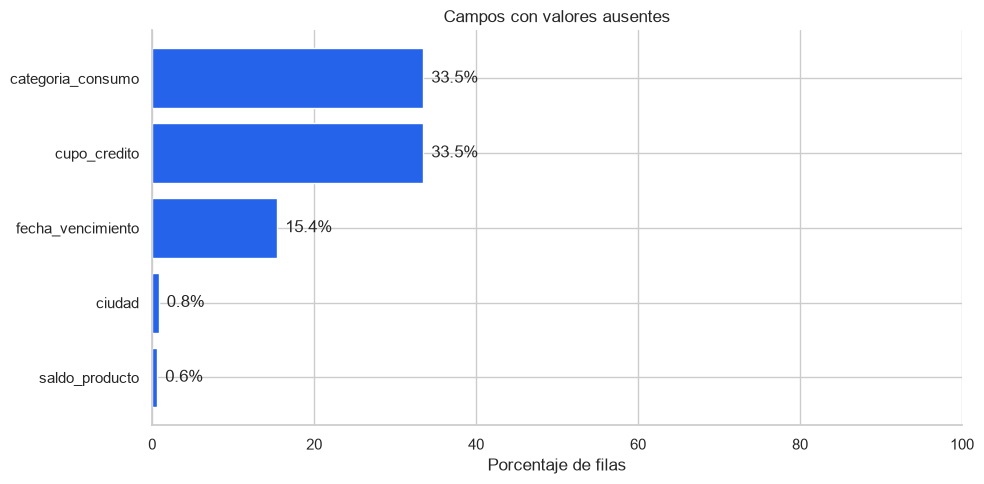

In [5]:
null_profile = (
    pd.DataFrame(
        {
            "Nulos": data.isna().sum(),
            "Porcentaje": data.isna().mean() * 100,
        }
    )
    .sort_values("Nulos", ascending=False)
    .rename_axis("Campo")
)
display(null_profile)

figure, axis = plt.subplots(figsize=(10, 5))
chart_data = null_profile[null_profile["Nulos"] > 0].sort_values("Porcentaje")
axis.barh(chart_data.index, chart_data["Porcentaje"], color="#2563EB")
axis.set_title("Campos con valores ausentes")
axis.set_xlabel("Porcentaje de filas")
axis.set_ylabel("")
axis.set_xlim(0, 100)
for position, value in enumerate(chart_data["Porcentaje"]):
    axis.text(value + 1, position, f"{value:.1f}%", va="center")
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
is_credit_card = data["producto"].eq("Tarjeta de Crédito")
is_deposit = data["producto"].isin(["Cuenta de Ahorros", "Cuenta Corriente"])
valid_city_clients = set(data.loc[data["ciudad"].notna(), "cliente_id"])

city_missing_rows = int(data["ciudad"].isna().sum())
recoverable_city_rows = int(
    (data["ciudad"].isna() & data["cliente_id"].isin(valid_city_clients)).sum()
)
clients_without_city = int(
    data.groupby("cliente_id")["ciudad"].apply(lambda values: values.notna().sum() == 0).sum()
)

data_without_exact_duplicates = data.drop_duplicates().copy()
product_groups = data_without_exact_duplicates.groupby(["cliente_id", "producto"])
product_groups_without_balance = int(
    product_groups["saldo_producto"].apply(lambda values: values.notna().sum() == 0).sum()
)

null_semantics = pd.DataFrame(
    [
        ["cupo_credito", "Estructural", int(data.loc[~is_credit_card, "cupo_credito"].isna().sum()), "No aplica fuera de tarjeta"],
        ["categoria_consumo", "Estructural", int(data.loc[~is_credit_card, "categoria_consumo"].isna().sum()), "No aplica fuera de tarjeta"],
        ["fecha_vencimiento", "Estructural", int(data.loc[is_deposit, "fecha_vencimiento"].isna().sum()), "No aplica a depósitos"],
        ["ciudad", "Recuperable", recoverable_city_rows, "Usar otra fila del mismo cliente"],
        ["ciudad", "No recuperable", clients_without_city, "Asignar Desconocida en Fase 2"],
        ["saldo_producto", "No recuperable", product_groups_without_balance, "Conservar nulo y agregar bandera"],
    ],
    columns=["Campo", "Clasificación", "Casos", "Tratamiento propuesto"],
)
display(null_semantics)

structural_null_checks = pd.DataFrame(
    {
        "Regla": [
            "Cupo nulo fuera de tarjeta",
            "Categoría nula fuera de tarjeta",
            "Vencimiento nulo en depósitos",
            "Cupo informado solo en tarjeta",
            "Consumo cero fuera de tarjeta",
        ],
        "Resultado": [
            bool(data.loc[~is_credit_card, "cupo_credito"].isna().all()),
            bool(data.loc[~is_credit_card, "categoria_consumo"].isna().all()),
            bool(data.loc[is_deposit, "fecha_vencimiento"].isna().all()),
            bool(data.loc[data["cupo_credito"].notna(), "producto"].eq("Tarjeta de Crédito").all()),
            bool(data.loc[~is_credit_card, "monto_consumo"].eq(0).all()),
        ],
    }
)
display(structural_null_checks)

,Campo,Clasificación,Casos,Tratamiento propuesto
0,cupo_credito,Estructural,7513,No aplica fuera de tarjeta
1,categoria_consumo,Estructural,7513,No aplica fuera de tarjeta
2,fecha_vencimiento,Estructural,3464,No aplica a depósitos
3,ciudad,Recuperable,177,Usar otra fila del mismo cliente
4,ciudad,No recuperable,1,Asignar Desconocida en Fase 2
5,saldo_producto,No recuperable,8,Conservar nulo y agregar bandera


,Regla,Resultado
0,Cupo nulo fuera de tarjeta,True
1,Categoría nula fuera de tarjeta,True
2,Vencimiento nulo en depósitos,True
3,Cupo informado solo en tarjeta,True
4,Consumo cero fuera de tarjeta,True


### 6. Unicidad: duplicados exactos frente a registros repetidos

In [7]:
exact_duplicate_count = int(data.duplicated().sum())
rows_in_duplicate_sets = int(data.duplicated(keep=False).sum())

duplicate_summary = pd.DataFrame(
    {
        "Métrica": ["Duplicados adicionales", "Filas involucradas", "% de filas adicionales"],
        "Valor": [
            exact_duplicate_count,
            rows_in_duplicate_sets,
            exact_duplicate_count / len(data) * 100,
        ],
    }
)
display(duplicate_summary)

duplicates_by_product = (
    data.loc[data.duplicated(keep="first"), "producto"]
    .value_counts()
    .rename_axis("Producto")
    .to_frame("Duplicados adicionales")
)
display(duplicates_by_product)

,Métrica,Valor
0,Duplicados adicionales,113.00
1,Filas involucradas,226.00
2,% de filas adicionales,0.50


,Duplicados adicionales
Producto,
Tarjeta de Crédito,69
Cuenta de Ahorros,11
Cuenta Corriente,10
Crédito Hipotecario,9
Crédito Vehicular,8
Crédito de Consumo,6


In [8]:
client_product_sizes = (
    data_without_exact_duplicates.groupby(["cliente_id", "producto"])
    .size()
    .rename("registros")
    .reset_index()
)
client_product_group_count = len(client_product_sizes)
repeated_client_product_groups = int((client_product_sizes["registros"] > 1).sum())

repetitions_by_product = (
    client_product_sizes.groupby("producto")
    .agg(
        combinaciones=("cliente_id", "size"),
        combinaciones_repetidas=("registros", lambda values: int((values > 1).sum())),
        registros_promedio=("registros", "mean"),
        maximo_registros=("registros", "max"),
    )
    .sort_values("combinaciones_repetidas", ascending=False)
)
display(repetitions_by_product)

display(
    Markdown(
        f"**Lectura:** hay {client_product_group_count:,} combinaciones cliente-producto; "
        f"{repeated_client_product_groups:,} tienen varias filas. Estas repeticiones aparecen "
        "en todos los tipos de producto y no deben confundirse con duplicados exactos."
    )
)

,combinaciones,combinaciones_repetidas,registros_promedio,maximo_registros
producto,,,,
Tarjeta de Crédito,1655,1655,8.99,14
Cuenta de Ahorros,693,510,2.50,4
Cuenta Corriente,676,506,2.53,4
Crédito de Consumo,705,486,2.03,3
Crédito Hipotecario,687,443,1.99,3
Crédito Vehicular,632,402,1.94,3


**Lectura:** hay 5,048 combinaciones cliente-producto; 4,002 tienen varias filas. Estas repeticiones aparecen en todos los tipos de producto y no deben confundirse con duplicados exactos.

### 7. Consistencia de categorías

In [9]:
categorical_columns = [
    "segmento_cliente",
    "ciudad",
    "producto",
    "categoria_consumo",
    "canal",
    "estado_producto",
]

category_cardinality = pd.DataFrame(
    {
        "Campo": categorical_columns,
        "Valores distintos literales": [data_text[column].nunique() for column in categorical_columns],
        "Valores distintos analíticos": [data[column].nunique(dropna=True) for column in categorical_columns],
    }
)
display(category_cardinality)

segment_counts = data_text["segmento_cliente"].value_counts().to_frame("Filas")
consumption_category_counts = data_text["categoria_consumo"].value_counts().to_frame("Filas")
display(segment_counts)
display(consumption_category_counts)

,Campo,Valores distintos literales,Valores distintos analíticos
0,segmento_cliente,10,10
1,ciudad,7,6
2,producto,6,6
3,categoria_consumo,16,15
4,canal,5,5
5,estado_producto,1,1


,Filas
segmento_cliente,
Mass,9962
Affluent,4392
Premium,3059
Joven,2734
PyME,2037
pyme,58
Affluent,58
mass,56
JOVEN,54


,Filas
categoria_consumo,
N/A,7513
Supermarket,2221
Food,2171
Travel,1735
Streaming,1728
Technology,1668
Entertainment,1368
Others,1031
Health,995


In [10]:
normalization_candidates = pd.DataFrame(
    [
        ["segmento_cliente", "mass", "Mass", "Mayúsculas"],
        ["segmento_cliente", "JOVEN", "Joven", "Mayúsculas"],
        ["segmento_cliente", "Affluent ", "Affluent", "Espacio final"],
        ["segmento_cliente", "PREMIUM ", "Premium", "Mayúsculas y espacio"],
        ["segmento_cliente", "pyme", "PyME", "Mayúsculas"],
        ["categoria_consumo", "FOOD ", "Food", "Mayúsculas y espacio"],
        ["categoria_consumo", "streamng", "Streaming", "Error tipográfico"],
        ["categoria_consumo", "Travels", "Travel", "Plural"],
        ["categoria_consumo", "tech", "Technology", "Abreviación"],
        ["categoria_consumo", "Super Market", "Supermarket", "Espacio interno"],
    ],
    columns=["Campo", "Valor original", "Valor propuesto", "Problema"],
)
display(normalization_candidates)

,Campo,Valor original,Valor propuesto,Problema
0,segmento_cliente,mass,Mass,Mayúsculas
1,segmento_cliente,JOVEN,Joven,Mayúsculas
2,segmento_cliente,Affluent,Affluent,Espacio final
3,segmento_cliente,PREMIUM,Premium,Mayúsculas y espacio
4,segmento_cliente,pyme,PyME,Mayúsculas
5,categoria_consumo,FOOD,Food,Mayúsculas y espacio
6,categoria_consumo,streamng,Streaming,Error tipográfico
7,categoria_consumo,Travels,Travel,Plural
8,categoria_consumo,tech,Technology,Abreviación
9,categoria_consumo,Super Market,Supermarket,Espacio interno


### 8. Validez de fechas

In [11]:
def audit_dates(text_series: pd.Series) -> tuple[pd.Series, pd.Series, dict]:
    informed = ~text_series.isin(["", "N/A"])
    iso_format = informed & text_series.str.fullmatch(
        r"[0-9]{4}-[0-9]{2}-[0-9]{2}", na=False
    )
    alternative_format = informed & ~iso_format

    # Prueba solicitada: recupera todos los valores, pero puede intercambiar
    # mes y día en fechas ISO ambiguas cuando dayfirst=True.
    parsed_mixed = pd.to_datetime(
        text_series.replace({"": pd.NA, "N/A": pd.NA}),
        format="mixed",
        dayfirst=True,
        errors="coerce",
    )

    # Lectura segura propuesta para la Fase 2: cada patrón tiene su formato.
    parsed_strict = pd.Series(pd.NaT, index=text_series.index, dtype="datetime64[ns]")
    parsed_strict.loc[iso_format] = pd.to_datetime(
        text_series.loc[iso_format], format="%Y-%m-%d", errors="coerce"
    )
    parsed_strict.loc[alternative_format] = pd.to_datetime(
        text_series.loc[alternative_format], format="%d/%m/%Y", errors="coerce"
    )

    changed_by_mixed = int(
        (
            parsed_mixed.notna()
            & parsed_strict.notna()
            & parsed_mixed.ne(parsed_strict)
        ).sum()
    )
    summary = {
        "Valores informados": int(informed.sum()),
        "No ISO": int(alternative_format.sum()),
        "No interpretados (mixed)": int((informed & parsed_mixed.isna()).sum()),
        "No interpretados (estricto)": int((informed & parsed_strict.isna()).sum()),
        "Fechas alteradas por mixed + dayfirst": changed_by_mixed,
        "Fecha mínima segura": parsed_strict.min().date().isoformat(),
        "Fecha máxima segura": parsed_strict.max().date().isoformat(),
    }
    return parsed_strict, parsed_mixed, summary

movement_dates_parsed, movement_dates_mixed, movement_date_summary = audit_dates(
    data_text["fecha_movimiento"]
)
expiration_dates_parsed, expiration_dates_mixed, expiration_date_summary = audit_dates(
    data_text["fecha_vencimiento"]
)

date_audit = pd.DataFrame(
    [movement_date_summary, expiration_date_summary],
    index=["fecha_movimiento", "fecha_vencimiento"],
)
display(date_audit)

cutoff_date = movement_dates_parsed.max()
non_iso_movement_count = movement_date_summary["No ISO"]
invalid_mixed_movement_count = movement_date_summary["No interpretados (mixed)"]
invalid_strict_movement_count = movement_date_summary["No interpretados (estricto)"]
dates_changed_by_mixed = movement_date_summary[
    "Fechas alteradas por mixed + dayfirst"
]
display(
    Markdown(
        f"**Fecha de corte reproducible:** {cutoff_date.date().isoformat()}. "
        f"La lectura mixta no pierde fechas, pero altera {dates_changed_by_mixed:,} "
        "valores ISO ambiguos; por eso no se utilizará sola en la limpieza."
    )
)

,Valores informados,No ISO,No interpretados (mixed),No interpretados (estricto),Fechas alteradas por mixed + dayfirst,Fecha mínima segura,Fecha máxima segura
fecha_movimiento,22455,89,0,0,8182,2025-01-01,2026-08-31
fecha_vencimiento,18991,0,0,0,6902,2026-09-17,2032-09-08


**Fecha de corte reproducible:** 2026-08-31. La lectura mixta no pierde fechas, pero altera 8,182 valores ISO ambiguos; por eso no se utilizará sola en la limpieza.

### 9. Variables numéricas y valores extremos

In [12]:
numeric_columns = [
    "edad",
    "ingreso_estimado",
    "saldo_producto",
    "cupo_credito",
    "monto_consumo",
]

numeric_summary = data[numeric_columns].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T
display(numeric_summary)

numeric_quality = pd.DataFrame(
    {
        "Nulos": data[numeric_columns].isna().sum(),
        "Ceros": [(data[column] == 0).sum() for column in numeric_columns],
        "Negativos": [(data[column] < 0).sum() for column in numeric_columns],
    }
)
display(numeric_quality)

,count,mean,std,min,1%,25%,50%,75%,99%,max
edad,"22,455.00",38.74,11.38,18.00,18.00,31.00,39.00,47.00,66.00,78.00
ingreso_estimado,"22,455.00","1,881.73","1,539.29",350.00,366.30,798.77,"1,255.17","2,534.15","7,075.74","16,177.54"
saldo_producto,"22,319.00","7,611.06","19,006.17",-100.00,-100.00,468.68,"1,280.13","4,040.84","99,999.47","158,165.51"
cupo_credito,"14,942.00","3,710.43","3,360.03",500.00,600.00,"1,500.00","2,500.00","4,700.00","16,500.00","29,300.00"
monto_consumo,"22,455.00",83.33,156.41,0.00,0.00,0.00,32.30,97.87,724.87,"3,712.08"


,Nulos,Ceros,Negativos
edad,0,0,0
ingreso_estimado,0,0,0
saldo_producto,136,776,302
cupo_credito,7513,0,0
monto_consumo,0,7513,0


In [13]:
balance_by_product = (
    data.groupby("producto")["saldo_producto"]
    .agg(
        registros="count",
        nulos=lambda values: int(values.isna().sum()),
        negativos=lambda values: int((values < 0).sum()),
        ceros=lambda values: int((values == 0).sum()),
        mediana="median",
        minimo="min",
        maximo="max",
    )
    .sort_values("mediana")
)
display(balance_by_product)

negative_balance_products = set(
    data.loc[data["saldo_producto"] < 0, "producto"].unique()
)

,registros,nulos,negativos,ceros,mediana,minimo,maximo
producto,,,,,,,
Tarjeta de Crédito,14852,90,0,772,718.83,0.00,"18,157.12"
Cuenta de Ahorros,1733,8,149,0,"2,506.57",-100.00,"49,425.12"
Cuenta Corriente,1712,11,153,0,"2,651.17",-100.00,"35,349.58"
Crédito de Consumo,1427,12,0,0,"5,859.37",115.30,"43,034.16"
Crédito Vehicular,1228,4,0,1,"17,983.16",0.00,"38,261.64"
Crédito Hipotecario,1367,11,0,3,"74,186.47",0.00,"158,165.51"


> **Criterio:** IQR identifica valores alejados de la distribución de su grupo. Una bandera estadística no demuestra que el dato sea erróneo. Por eso la Fase 2 conservará el valor y añadirá una marca de revisión.

In [14]:
def iqr_profile(frame: pd.DataFrame, group_column: str, value_column: str) -> pd.DataFrame:
    rows = []
    for group_name, values in frame.groupby(group_column)[value_column]:
        valid_values = values.dropna()
        q1 = valid_values.quantile(0.25)
        q3 = valid_values.quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        outlier_count = int(
            ((valid_values < lower_limit) | (valid_values > upper_limit)).sum()
        )
        rows.append(
            {
                "Grupo": group_name,
                "Observaciones": len(valid_values),
                "Q1": q1,
                "Q3": q3,
                "Límite inferior": lower_limit,
                "Límite superior": upper_limit,
                "Posibles outliers": outlier_count,
                "% posibles outliers": outlier_count / len(valid_values) * 100,
            }
        )
    return pd.DataFrame(rows).set_index("Grupo")

balance_iqr = iqr_profile(data, "producto", "saldo_producto")
positive_consumptions = data.loc[
    data["monto_consumo"].gt(0) & data["categoria_consumo"].notna()
]
consumption_iqr = iqr_profile(
    positive_consumptions,
    "categoria_consumo",
    "monto_consumo",
)

display(balance_iqr)
display(consumption_iqr.sort_values("% posibles outliers", ascending=False))

,Observaciones,Q1,Q3,Límite inferior,Límite superior,Posibles outliers,% posibles outliers
Grupo,,,,,,,
Crédito Hipotecario,1367,"56,506.19","90,600.90","5,364.13","141,742.96",15,1.10
Crédito Vehicular,1228,"13,851.00","22,115.73","1,453.91","34,512.82",11,0.90
Crédito de Consumo,1427,"3,685.74","13,233.53","-10,635.95","27,555.23",38,2.66
Cuenta Corriente,1712,"1,200.87","6,341.33","-6,509.82","14,052.02",72,4.21
Cuenta de Ahorros,1733,"1,139.31","5,679.82","-5,671.45","12,490.58",148,8.54
Tarjeta de Crédito,14852,356.20,"1,536.17","-1,413.77","3,306.14",1138,7.66


,Observaciones,Q1,Q3,Límite inferior,Límite superior,Posibles outliers,% posibles outliers
Grupo,,,,,,,
Travels,29,48.20,118.85,-57.77,224.82,6,20.69
streamng,30,32.07,87.51,-51.08,170.67,4,13.33
Super Market,18,29.10,119.33,-106.26,254.69,2,11.11
Education,947,33.67,148.65,-138.79,321.12,83,8.76
Others,1031,32.09,154.06,-150.84,337.00,88,8.54
Streaming,1728,32.45,145.12,-136.54,314.11,147,8.51
Travel,1735,32.86,154.56,-149.69,337.12,147,8.47
FOOD,36,25.34,188.76,-219.77,433.88,3,8.33
Food,2171,33.98,147.29,-136.00,317.26,177,8.15


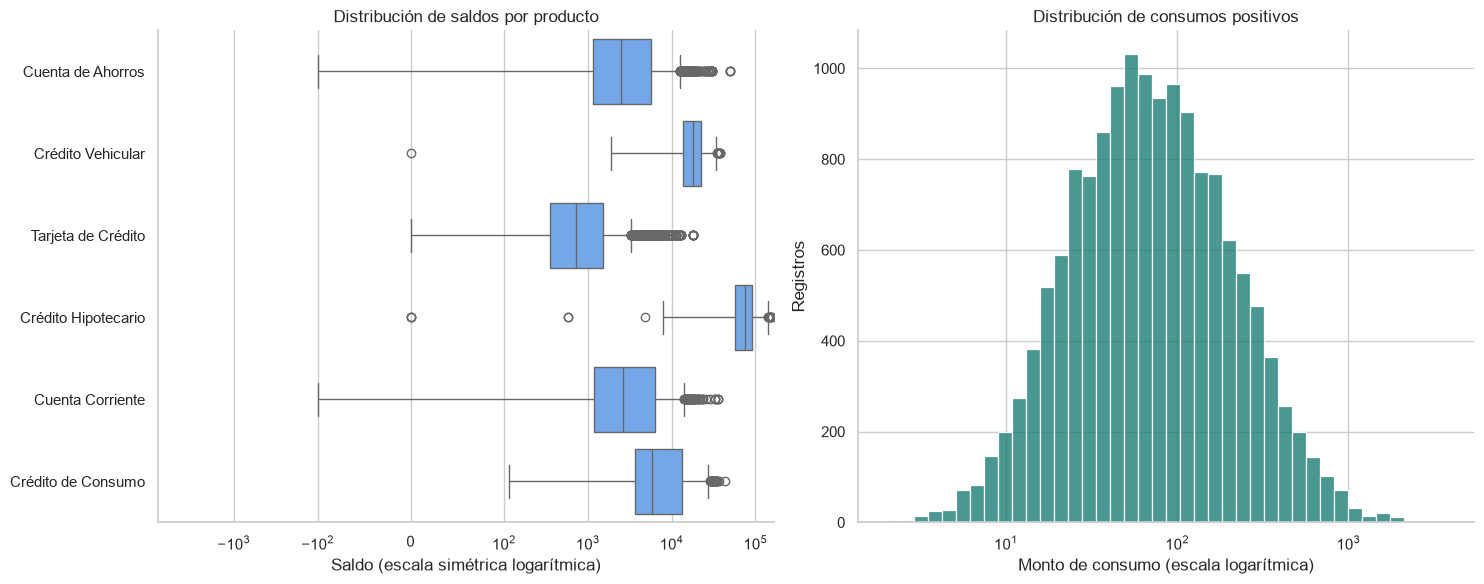

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=data,
    y="producto",
    x="saldo_producto",
    color="#60A5FA",
    ax=axes[0],
)
axes[0].set_xscale("symlog", linthresh=100)
axes[0].set_title("Distribución de saldos por producto")
axes[0].set_xlabel("Saldo (escala simétrica logarítmica)")
axes[0].set_ylabel("")

sns.histplot(
    positive_consumptions,
    x="monto_consumo",
    bins=40,
    log_scale=(True, False),
    color="#0F766E",
    ax=axes[1],
)
axes[1].set_title("Distribución de consumos positivos")
axes[1].set_xlabel("Monto de consumo (escala logarítmica)")
axes[1].set_ylabel("Registros")

sns.despine()
plt.tight_layout()
plt.show()

### 10. Consistencia de clientes y productos

In [16]:
client_attributes = [
    "nombre_cliente",
    "segmento_cliente",
    "ciudad",
    "edad",
    "ingreso_estimado",
]

client_conflicts = pd.DataFrame(
    {
        "Clientes con más de una versión, contando nulos": {
            column: int(
                (
                    data_without_exact_duplicates.groupby("cliente_id")[column]
                    .nunique(dropna=False)
                    > 1
                ).sum()
            )
            for column in client_attributes
        },
        "Clientes con más de una versión no nula": {
            column: int(
                (
                    data_without_exact_duplicates.groupby("cliente_id")[column]
                    .nunique(dropna=True)
                    > 1
                ).sum()
            )
            for column in client_attributes
        },
    }
)

segment_normalized_for_audit = (
    data_without_exact_duplicates["segmento_cliente"]
    .astype("string")
    .str.strip()
    .str.casefold()
)
segment_conflicts_after_normalization = int(
    segment_normalized_for_audit.groupby(data_without_exact_duplicates["cliente_id"])
    .nunique(dropna=True)
    .gt(1)
    .sum()
)
segment_conflicts_raw = int(
    client_conflicts.loc[
        "segmento_cliente",
        "Clientes con más de una versión no nula",
    ]
)
segment_conflicts_resolved_by_formatting = (
    segment_conflicts_raw - segment_conflicts_after_normalization
)

unresolved_segment_examples = (
    data_without_exact_duplicates.assign(
        segmento_normalizado=segment_normalized_for_audit
    )
    .groupby("cliente_id")["segmento_normalizado"]
    .agg(lambda values: sorted(values.dropna().unique().tolist()))
)
unresolved_segment_examples = unresolved_segment_examples.loc[
    unresolved_segment_examples.str.len().gt(1)
].head(10).to_frame("Segmentos normalizados observados")

display(client_conflicts)
display(
    Markdown(
        f"De los **{segment_conflicts_raw} clientes** con más de un segmento literal, "
        f"solo **{segment_conflicts_resolved_by_formatting}** se explican por mayúsculas o espacios. "
        f"Quedan **{segment_conflicts_after_normalization} clientes con segmentos canónicos distintos**. "
        "Sin una regla de negocio no es correcto escoger uno silenciosamente."
    )
)
display(unresolved_segment_examples)

,"Clientes con más de una versión, contando nulos",Clientes con más de una versión no nula
nombre_cliente,0,0
segmento_cliente,251,251
ciudad,170,0
edad,0,0
ingreso_estimado,0,0


De los **251 clientes** con más de un segmento literal, solo **40** se explican por mayúsculas o espacios. Quedan **211 clientes con segmentos canónicos distintos**. Sin una regla de negocio no es correcto escoger uno silenciosamente.

,Segmentos normalizados observados
cliente_id,
C000001,"[affluent, mass]"
C000002,"[mass, pyme]"
C000019,"[mass, premium]"
C000024,"[mass, premium]"
C000050,"[affluent, mass]"
C000067,"[joven, premium]"
C000078,"[affluent, mass]"
C000082,"[affluent, mass]"
C000084,"[joven, premium]"


In [17]:
product_attribute_conflicts = pd.DataFrame(
    {
        column: product_groups[column]
        .nunique(dropna=True)
        .gt(1)
        .value_counts()
        .reindex([False, True], fill_value=0)
        for column in ["saldo_producto", "cupo_credito", "fecha_vencimiento"]
    }
).T
product_attribute_conflicts.columns = ["Grupos consistentes", "Grupos con conflicto"]
display(product_attribute_conflicts)

,Grupos consistentes,Grupos con conflicto
saldo_producto,5048,0
cupo_credito,5048,0
fecha_vencimiento,5048,0


### 11. Riesgo de doble conteo

In [18]:
product_snapshot_for_audit = (
    product_groups["saldo_producto"]
    .first()
    .rename("saldo_producto")
    .reset_index()
)

raw_balance_total = float(data["saldo_producto"].sum())
deduplicated_row_balance_total = float(data_without_exact_duplicates["saldo_producto"].sum())
product_level_balance_total = float(product_snapshot_for_audit["saldo_producto"].sum())

raw_card_balance = float(
    data.loc[data["producto"].eq("Tarjeta de Crédito"), "saldo_producto"].sum()
)
product_level_card_balance = float(
    product_snapshot_for_audit.loc[
        product_snapshot_for_audit["producto"].eq("Tarjeta de Crédito"),
        "saldo_producto",
    ].sum()
)

balance_reconciliation = pd.DataFrame(
    [
        ["Todas las filas originales", raw_balance_total, raw_balance_total / product_level_balance_total],
        ["Filas sin duplicados exactos", deduplicated_row_balance_total, deduplicated_row_balance_total / product_level_balance_total],
        ["Una fila por cliente-producto", product_level_balance_total, 1.0],
        ["Tarjetas: todas las filas", raw_card_balance, raw_card_balance / product_level_card_balance],
        ["Tarjetas: una fila por cliente-producto", product_level_card_balance, 1.0],
    ],
    columns=["Cálculo", "Saldo", "Factor frente a producto"],
)
display(balance_reconciliation)

display(
    Markdown(
        f"Sumar desde el archivo original infla el saldo general **{raw_balance_total / product_level_balance_total:.2f} veces**. "
        f"En tarjetas, el factor llega a **{raw_card_balance / product_level_card_balance:.2f} veces**. "
        "Por esta razón la Fase 2 separará productos de consumos."
    )
)

,Cálculo,Saldo,Factor frente a producto
0,Todas las filas originales,"169,871,166.14",2.20
1,Filas sin duplicados exactos,"168,666,319.46",2.18
2,Una fila por cliente-producto,"77,356,909.02",1.00
3,Tarjetas: todas las filas,"18,042,718.54",8.94
4,Tarjetas: una fila por cliente-producto,"2,018,033.83",1.00


Sumar desde el archivo original infla el saldo general **2.20 veces**. En tarjetas, el factor llega a **8.94 veces**. Por esta razón la Fase 2 separará productos de consumos.

### 12. Hallazgos de calidad y contrato de limpieza

In [19]:
quality_findings = pd.DataFrame(
    [
        ["Granularidad mixta", "Saldo general inflado 2,20 veces", "Separar productos de registros y consumos", "Crítico: KPIs financieros erróneos", "Reconciliar suma cruda contra una fila cliente-producto"],
        ["Sin ID transaccional", "No se puede probar que dos compras idénticas sean la misma", "Documentar supuesto y crear ID determinista", "Alto: eliminar una operación real", "Conservar trazabilidad y contar filas antes/después"],
        ["Duplicados exactos", "113 filas adicionales (0,50%)", "Eliminar solo coincidencias exactas", "Medio: sobreconteo", "Esperar 22.342 registros tras deduplicar"],
        ["Categorías inconsistentes", "10 variantes conocidas", "Aplicar diccionarios explícitos", "Medio: categorías fragmentadas", "Lista cerrada y cero variantes conocidas remanentes"],
        ["Segmento conflictivo por cliente", "211 clientes conservan más de un segmento tras normalizar formato", "Definir regla determinista y conservar bandera", "Alto: perfil comercial ambiguo", "Una fila por cliente más indicador de conflicto"],
        ["Fechas mixtas", "89 alternativas; mixed + dayfirst altera 8.182 ISO ambiguas", "Detectar patrón y parsear cada formato explícitamente", "Alto: recencia y corte equivocados", "Cero inválidas y rango 2025-01-01 a 2026-08-31"],
        ["Ciudad y saldo incompletos", "178 filas de ciudad y 136 de saldo", "Recuperar dentro de entidad; conservar excepción", "Medio: filtros y saldos incompletos", "Un cliente sin ciudad y ocho productos sin saldo"],
        ["Negativos y extremos", "Solo hay negativos en depósitos; IQR marca extremos", "Conservar valor y agregar bandera", "Bajo: pérdida si se corrige sin negocio", "Mismo valor original y bandera auditable"],
    ],
    columns=["Problema", "Evidencia", "Tratamiento propuesto", "Riesgo", "Validación de Fase 2"],
)
display(quality_findings)

cleaning_contract = pd.DataFrame(
    [
        ["dataset_clean.csv", "Registro fuente no duplicado", "Preservar fecha, canal y campos normalizados"],
        ["dim_clientes.csv", "Un cliente", "Atributos estables para filtros"],
        ["fact_productos.csv", "Un cliente-producto", "Saldos, cupos y vencimientos sin repetición"],
        ["fact_consumos.csv", "Un consumo positivo de tarjeta", "Categorías, montos y comportamiento"],
        ["cliente_360.csv / .json", "Un cliente", "Consumo por React y análisis ejecutivo"],
    ],
    columns=["Salida de Fase 2", "Granularidad", "Propósito"],
)
display(cleaning_contract)

,Problema,Evidencia,Tratamiento propuesto,Riesgo,Validación de Fase 2
0,Granularidad mixta,"Saldo general inflado 2,20 veces",Separar productos de registros y consumos,Crítico: KPIs financieros erróneos,Reconciliar suma cruda contra una fila cliente...
1,Sin ID transaccional,No se puede probar que dos compras idénticas s...,Documentar supuesto y crear ID determinista,Alto: eliminar una operación real,Conservar trazabilidad y contar filas antes/de...
2,Duplicados exactos,"113 filas adicionales (0,50%)",Eliminar solo coincidencias exactas,Medio: sobreconteo,Esperar 22.342 registros tras deduplicar
3,Categorías inconsistentes,10 variantes conocidas,Aplicar diccionarios explícitos,Medio: categorías fragmentadas,Lista cerrada y cero variantes conocidas reman...
4,Segmento conflictivo por cliente,211 clientes conservan más de un segmento tras...,Definir regla determinista y conservar bandera,Alto: perfil comercial ambiguo,Una fila por cliente más indicador de conflicto
5,Fechas mixtas,89 alternativas; mixed + dayfirst altera 8.182...,Detectar patrón y parsear cada formato explíci...,Alto: recencia y corte equivocados,Cero inválidas y rango 2025-01-01 a 2026-08-31
6,Ciudad y saldo incompletos,178 filas de ciudad y 136 de saldo,Recuperar dentro de entidad; conservar excepción,Medio: filtros y saldos incompletos,Un cliente sin ciudad y ocho productos sin saldo
7,Negativos y extremos,Solo hay negativos en depósitos; IQR marca ext...,Conservar valor y agregar bandera,Bajo: pérdida si se corrige sin negocio,Mismo valor original y bandera auditable


,Salida de Fase 2,Granularidad,Propósito
0,dataset_clean.csv,Registro fuente no duplicado,"Preservar fecha, canal y campos normalizados"
1,dim_clientes.csv,Un cliente,Atributos estables para filtros
2,fact_productos.csv,Un cliente-producto,"Saldos, cupos y vencimientos sin repetición"
3,fact_consumos.csv,Un consumo positivo de tarjeta,"Categorías, montos y comportamiento"
4,cliente_360.csv / .json,Un cliente,Consumo por React y análisis ejecutivo


### 13. Validaciones automáticas

In [20]:
product_conflict_counts = {
    column: int(product_groups[column].nunique(dropna=True).gt(1).sum())
    for column in ["saldo_producto", "cupo_credito", "fecha_vencimiento"]
}

assert data.shape == (22455, 15)
assert data["cliente_id"].nunique() == 2200
assert exact_duplicate_count == 113
assert city_missing_rows == 178
assert int(data["saldo_producto"].isna().sum()) == 136
assert int(data["cupo_credito"].isna().sum()) == 7513
assert int(data["categoria_consumo"].isna().sum()) == 7513
assert int(data["fecha_vencimiento"].isna().sum()) == 3464
assert clients_without_city == 1
assert structural_null_checks["Resultado"].all()
assert non_iso_movement_count == 89
assert invalid_mixed_movement_count == 0
assert invalid_strict_movement_count == 0
assert dates_changed_by_mixed == 8182
assert client_product_group_count == 5048
assert repeated_client_product_groups == 4002
assert product_groups_without_balance == 8
assert product_conflict_counts == {
    "saldo_producto": 0,
    "cupo_credito": 0,
    "fecha_vencimiento": 0,
}
assert negative_balance_products == {"Cuenta de Ahorros", "Cuenta Corriente"}
assert segment_conflicts_raw == 251
assert segment_conflicts_resolved_by_formatting == 40
assert segment_conflicts_after_normalization == 211
assert cutoff_date.date().isoformat() == "2026-08-31"
assert abs(raw_balance_total - 169871166.14) < 0.01
assert abs(product_level_balance_total - 77356909.02) < 0.01
assert abs(raw_card_balance - 18042718.54) < 0.01
assert abs(product_level_card_balance - 2018033.83) < 0.01

print("Todas las validaciones de la Fase 1 se ejecutaron correctamente.")

Todas las validaciones de la Fase 1 se ejecutaron correctamente.


## Cierre de la Parte I: auditoría

1. **El dataset puede utilizarse después de una limpieza controlada.** La mayoría de los problemas son consistentes y tienen una regla defendible.
2. **La granularidad es el riesgo de mayor impacto.** Los KPIs de cartera deben calcularse desde una tabla cliente-producto, no desde los registros originales.
3. **Los nulos deben tratarse según contexto.** Algunos significan “no aplica”; otros pueden recuperarse y ocho productos conservarán saldo desconocido.
4. **Las fechas son recuperables con lectura explícita.** Los 89 valores no ISO son válidos bajo formato día/mes/año; aplicar `mixed + dayfirst` a toda la columna alteraría 8.182 fechas ISO ambiguas.
5. **Los extremos no se eliminarán.** Se conservarán con banderas para evitar destruir información potencialmente real.
6. **El segmento requiere una regla de consolidación.** De 251 clientes con más de una etiqueta, 40 se resuelven por formato; 211 conservan segmentos realmente distintos y deben quedar señalados hasta acordar una precedencia.

### Qué debes poder explicar

- El archivo mezcla información de cliente, fotografía de producto e interacción o consumo.
- Un registro repetido no es automáticamente un duplicado.
- Un nulo no es automáticamente cero.
- Consolidar producto antes de sumar evita inflar el saldo.
- Normalizar texto corrige etiquetas, pero no resuelve conflictos semánticos entre segmentos distintos.
- La Fase 2 implementará las reglas propuestas y exportará las cinco vistas del contrato.

**Estado de esta auditoría:** completada. La Parte II aplica a continuación las reglas justificadas por esta evidencia.

# Parte II — Limpieza y modelo analítico

Esta parte transforma una copia en memoria; el TSV original nunca se sobrescribe. Cada regla responde a un hallazgo de la auditoría y conserva trazabilidad mediante IDs técnicos, línea de origen y banderas de calidad.

## Objetivo y contratos

- `data/dataset_clean.csv`: registro limpio y no duplicado; entregable principal del PDF.
- `dim_clientes.csv`: una fila por cliente.
- `fact_productos.csv`: una fila por cliente-producto.
- `fact_consumos.csv`: una fila por consumo positivo de tarjeta.
- `cliente_360.csv/json`: una fila por cliente para consumo analítico y React.
- `data_quality_report.json`: controles, reconciliaciones y huellas de los archivos.

En esta fase no se calculan Lovers ni se generan insights comerciales definitivos.

## 14. Parámetros, diccionarios y funciones de limpieza

In [21]:
import json
from importlib import metadata

CLEAN_DATASET_PATH = PROJECT_ROOT / "data" / "dataset_clean.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DIM_CLIENTS_PATH = PROCESSED_DIR / "dim_clientes.csv"
FACT_PRODUCTS_PATH = PROCESSED_DIR / "fact_productos.csv"
FACT_CONSUMPTIONS_PATH = PROCESSED_DIR / "fact_consumos.csv"
CLIENT_360_CSV_PATH = PROCESSED_DIR / "cliente_360.csv"
CLIENT_360_JSON_PATH = PROCESSED_DIR / "cliente_360.json"
QUALITY_REPORT_PATH = PROCESSED_DIR / "data_quality_report.json"

ORIGINAL_COLUMNS = data_text.columns.tolist()
DEPOSIT_PRODUCTS = {"Cuenta de Ahorros", "Cuenta Corriente"}

SEGMENT_MAP = {
    "mass": "Mass",
    "joven": "Joven",
    "affluent": "Affluent",
    "premium": "Premium",
    "pyme": "PyME",
}

CONSUMPTION_CATEGORY_MAP = {
    "education": "Education",
    "entertainment": "Entertainment",
    "food": "Food",
    "fuel": "Fuel",
    "health": "Health",
    "others": "Others",
    "streaming": "Streaming",
    "streamng": "Streaming",
    "supermarket": "Supermarket",
    "super market": "Supermarket",
    "technology": "Technology",
    "tech": "Technology",
    "travel": "Travel",
    "travels": "Travel",
}

PRODUCT_CODES = {
    "Cuenta de Ahorros": "CTA_AHORROS",
    "Cuenta Corriente": "CTA_CORRIENTE",
    "Tarjeta de Crédito": "TARJETA_CREDITO",
    "Crédito de Consumo": "CREDITO_CONSUMO",
    "Crédito Hipotecario": "CREDITO_HIPOTECARIO",
    "Crédito Vehicular": "CREDITO_VEHICULAR",
}


def normalize_with_map(series: pd.Series, value_map: dict) -> pd.Series:
    normalized_key = series.astype("string").str.strip().str.casefold()
    return normalized_key.map(value_map).astype("string")


def parse_dates_by_pattern(series: pd.Series) -> tuple[pd.Series, dict]:
    text = series.astype("string")
    informed = text.notna() & ~text.isin(["", "N/A"])
    iso_mask = informed & text.str.fullmatch(
        r"[0-9]{4}-[0-9]{2}-[0-9]{2}", na=False
    )
    day_first_mask = informed & text.str.fullmatch(
        r"[0-9]{2}/[0-9]{2}/[0-9]{4}", na=False
    )
    unknown_pattern = informed & ~iso_mask & ~day_first_mask

    parsed = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    parsed.loc[iso_mask] = pd.to_datetime(
        text.loc[iso_mask], format="%Y-%m-%d", errors="coerce"
    )
    parsed.loc[day_first_mask] = pd.to_datetime(
        text.loc[day_first_mask], format="%d/%m/%Y", errors="coerce"
    )

    result = {
        "informadas": int(informed.sum()),
        "iso": int(iso_mask.sum()),
        "dia_primero": int(day_first_mask.sum()),
        "patron_desconocido": int(unknown_pattern.sum()),
        "invalidas": int((informed & parsed.isna()).sum()),
    }
    return parsed, result


def iqr_thresholds(
    frame: pd.DataFrame, group_column: str, value_column: str
) -> pd.DataFrame:
    quartiles = (
        frame.groupby(group_column, observed=True)[value_column]
        .quantile([0.25, 0.75])
        .unstack()
        .rename(columns={0.25: "q1", 0.75: "q3"})
    )
    quartiles["iqr"] = quartiles["q3"] - quartiles["q1"]
    quartiles["limite_inferior"] = quartiles["q1"] - 1.5 * quartiles["iqr"]
    quartiles["limite_superior"] = quartiles["q3"] + 1.5 * quartiles["iqr"]
    return quartiles


def file_sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

## 15. Duplicados e identificadores técnicos

La deduplicación ocurre antes de normalizar. Así solo se eliminan filas que eran idénticas en las 15 columnas recibidas y no operaciones que se vuelvan parecidas después de corregir etiquetas.

`fila_origen` cuenta líneas del TSV, incluyendo el encabezado. Los IDs sirven para trazabilidad técnica; no reemplazan un identificador transaccional de la fuente.

In [22]:
source_with_lineage = data_text.copy()
source_with_lineage["fila_origen"] = np.arange(2, len(source_with_lineage) + 2)

exact_duplicate_mask = source_with_lineage[ORIGINAL_COLUMNS].duplicated(
    keep="first"
)
clean_text = source_with_lineage.loc[~exact_duplicate_mask].copy()
clean = data.loc[~exact_duplicate_mask].copy()
clean["fila_origen"] = clean_text["fila_origen"].astype("int64")
clean["registro_id"] = clean["fila_origen"].map(
    lambda row_number: f"REG-{row_number:06d}"
)

deduplication_result = pd.DataFrame(
    {
        "Métrica": [
            "Filas originales",
            "Duplicados exactos eliminados",
            "Filas limpias",
            "IDs de registro únicos",
        ],
        "Valor": [
            len(data),
            int(exact_duplicate_mask.sum()),
            len(clean),
            clean["registro_id"].nunique(),
        ],
    }
)
display(deduplication_result)

,Métrica,Valor
0,Filas originales,22455
1,Duplicados exactos eliminados,113
2,Filas limpias,22342
3,IDs de registro únicos,22342


## 16. Normalización de categorías y fechas

In [23]:
clean["segmento_cliente_observado"] = normalize_with_map(
    clean["segmento_cliente"], SEGMENT_MAP
)
clean["categoria_consumo"] = normalize_with_map(
    clean["categoria_consumo"], CONSUMPTION_CATEGORY_MAP
)

movement_dates_clean, movement_parse_result = parse_dates_by_pattern(
    clean_text["fecha_movimiento"]
)
expiration_dates_clean, expiration_parse_result = parse_dates_by_pattern(
    clean_text["fecha_vencimiento"]
)
clean["fecha_movimiento"] = movement_dates_clean
clean["fecha_vencimiento"] = expiration_dates_clean

clean["edad"] = pd.to_numeric(clean["edad"], errors="coerce").astype("Int64")
for numeric_column in [
    "ingreso_estimado",
    "saldo_producto",
    "cupo_credito",
    "monto_consumo",
]:
    clean[numeric_column] = pd.to_numeric(
        clean[numeric_column], errors="coerce"
    ).astype("Float64")

clean["tipo_producto"] = np.where(
    clean["producto"].isin(DEPOSIT_PRODUCTS), "Depósito", "Deuda"
)

normalization_result = pd.DataFrame(
    [
        ["Segmentos", clean["segmento_cliente_observado"].nunique(), 0],
        ["Categorías de consumo", clean["categoria_consumo"].nunique(), 0],
        [
            "Fecha de movimiento",
            movement_parse_result["informadas"],
            movement_parse_result["invalidas"],
        ],
        [
            "Fecha de vencimiento",
            expiration_parse_result["informadas"],
            expiration_parse_result["invalidas"],
        ],
    ],
    columns=["Control", "Valores o filas informadas", "Inválidas"],
)
display(normalization_result)

,Control,Valores o filas informadas,Inválidas
0,Segmentos,5,0
1,Categorías de consumo,10,0
2,Fecha de movimiento,22342,0
3,Fecha de vencimiento,18899,0


## 17. Consolidación del segmento comercial

El segmento final se elige por moda. Si dos segmentos empatan, se utiliza la última fecha en que apareció cada candidato. Un segundo empate se resolvería alfabéticamente como regla técnica neutral; en estos datos no es necesario usar ese último criterio.

La columna observada y la bandera de conflicto permiten auditar la decisión.

In [24]:
segment_frequency = (
    clean.groupby(
        ["cliente_id", "segmento_cliente_observado"],
        as_index=False,
        observed=True,
    )
    .agg(
        frecuencia=("registro_id", "size"),
        ultima_fecha=("fecha_movimiento", "max"),
    )
)
segment_frequency["frecuencia_maxima"] = segment_frequency.groupby(
    "cliente_id"
)["frecuencia"].transform("max")
mode_candidates = segment_frequency.loc[
    segment_frequency["frecuencia"].eq(
        segment_frequency["frecuencia_maxima"]
    )
].copy()
frequency_ties = mode_candidates.groupby("cliente_id").size().gt(1)

mode_candidates["ultima_fecha_maxima"] = mode_candidates.groupby(
    "cliente_id"
)["ultima_fecha"].transform("max")
recent_candidates = mode_candidates.loc[
    mode_candidates["ultima_fecha"].eq(
        mode_candidates["ultima_fecha_maxima"]
    )
].copy()
date_ties = recent_candidates.groupby("cliente_id").size().gt(1)

resolved_segment = (
    recent_candidates.sort_values(
        ["cliente_id", "segmento_cliente_observado"]
    )
    .drop_duplicates("cliente_id", keep="first")
    .set_index("cliente_id")["segmento_cliente_observado"]
)

observed_segment_count = clean.groupby("cliente_id")[
    "segmento_cliente_observado"
].nunique()
segment_method = pd.Series("unico", index=resolved_segment.index, dtype="string")
segment_method.loc[observed_segment_count.gt(1)] = "moda"
segment_method.loc[frequency_ties[frequency_ties].index] = (
    "moda_desempate_recencia"
)
segment_method.loc[date_ties[date_ties].index] = (
    "moda_desempate_alfabetico"
)

clean["segmento_cliente"] = clean["cliente_id"].map(resolved_segment)
clean["segmento_conflictivo"] = clean["cliente_id"].map(
    observed_segment_count.gt(1)
)
clean["segmento_metodo_resolucion"] = clean["cliente_id"].map(
    segment_method
)

segment_resolution_summary = pd.DataFrame(
    {
        "Método": segment_method.value_counts().index,
        "Clientes": segment_method.value_counts().values,
    }
)
display(segment_resolution_summary)
display(
    resolved_segment.value_counts()
    .sort_index()
    .rename_axis("Segmento final")
    .to_frame("Clientes")
)

,Método,Clientes
0,unico,1989
1,moda,209
2,moda_desempate_recencia,2


,Clientes
Segmento final,
Affluent,411
Joven,271
Mass,1024
Premium,281
PyME,213


## 18. Recuperación de ciudad y saldo

In [25]:
original_city_missing = clean["ciudad"].isna()
client_city = clean.groupby("cliente_id")["ciudad"].first()
mapped_city = clean["cliente_id"].map(client_city)
clean["ciudad_recuperada"] = original_city_missing & mapped_city.notna()
clean["ciudad_desconocida"] = mapped_city.isna()
clean["ciudad"] = clean["ciudad"].fillna(mapped_city).fillna("Desconocida")

product_key_columns = ["cliente_id", "producto"]
original_balance_missing = clean["saldo_producto"].isna()
product_balance = clean.groupby(product_key_columns)["saldo_producto"].first()
row_product_keys = pd.MultiIndex.from_frame(clean[product_key_columns])
mapped_balance = pd.Series(
    row_product_keys.map(product_balance),
    index=clean.index,
    dtype="Float64",
)
clean["saldo_recuperado"] = original_balance_missing & mapped_balance.notna()
clean["saldo_producto"] = clean["saldo_producto"].fillna(mapped_balance)
clean["saldo_desconocido"] = clean["saldo_producto"].isna()
clean["saldo_negativo"] = clean["saldo_producto"].lt(0).fillna(False)

recovery_summary = pd.DataFrame(
    [
        ["Ciudad", int(original_city_missing.sum()), int(clean["ciudad_recuperada"].sum()), int(clean["ciudad_desconocida"].sum())],
        ["Saldo", int(original_balance_missing.sum()), int(clean["saldo_recuperado"].sum()), int(clean["saldo_desconocido"].sum())],
    ],
    columns=["Campo", "Nulos después de deduplicar", "Recuperados", "No recuperados"],
)
display(recovery_summary)

,Campo,Nulos después de deduplicar,Recuperados,No recuperados
0,Ciudad,178,177,1
1,Saldo,134,126,8


## 19. Hecho de productos y outliers de saldo

In [26]:
clean["cliente_producto_id"] = (
    clean["cliente_id"]
    + "__"
    + clean["producto"].map(PRODUCT_CODES).astype("string")
)

product_fact = (
    clean.sort_values(
        ["cliente_id", "producto", "fecha_movimiento", "fila_origen"]
    )
    .groupby(product_key_columns, as_index=False)
    .agg(
        cliente_producto_id=("cliente_producto_id", "first"),
        tipo_producto=("tipo_producto", "first"),
        saldo_producto=("saldo_producto", "first"),
        cupo_credito=("cupo_credito", "first"),
        fecha_vencimiento=("fecha_vencimiento", "first"),
        estado_producto=("estado_producto", "first"),
        fecha_primer_registro=("fecha_movimiento", "min"),
        fecha_ultimo_registro=("fecha_movimiento", "max"),
        cantidad_registros=("registro_id", "size"),
    )
)
product_fact["saldo_desconocido"] = product_fact["saldo_producto"].isna()
product_fact["saldo_negativo"] = product_fact["saldo_producto"].lt(0).fillna(False)

balance_thresholds = iqr_thresholds(
    product_fact, "producto", "saldo_producto"
)
product_fact = product_fact.join(
    balance_thresholds[["limite_inferior", "limite_superior"]],
    on="producto",
)
product_fact["saldo_outlier_iqr"] = (
    product_fact["saldo_producto"].lt(product_fact["limite_inferior"])
    | product_fact["saldo_producto"].gt(product_fact["limite_superior"])
).fillna(False)
product_fact = product_fact.drop(
    columns=["limite_inferior", "limite_superior"]
)

product_outlier_map = product_fact.set_index("cliente_producto_id")[
    "saldo_outlier_iqr"
]
clean["saldo_outlier_iqr"] = clean["cliente_producto_id"].map(
    product_outlier_map
)

product_fact = product_fact[
    [
        "cliente_producto_id",
        "cliente_id",
        "producto",
        "tipo_producto",
        "saldo_producto",
        "saldo_desconocido",
        "saldo_negativo",
        "saldo_outlier_iqr",
        "cupo_credito",
        "fecha_vencimiento",
        "estado_producto",
        "fecha_primer_registro",
        "fecha_ultimo_registro",
        "cantidad_registros",
    ]
].sort_values(["cliente_id", "producto"], ignore_index=True)

display(balance_thresholds)
display(
    product_fact.groupby("producto")
    .agg(
        productos=("cliente_producto_id", "size"),
        saldo=("saldo_producto", "sum"),
        negativos=("saldo_negativo", "sum"),
        outliers=("saldo_outlier_iqr", "sum"),
    )
)

,q1,q3,iqr,limite_inferior,limite_superior
producto,,,,,
Crédito Hipotecario,"56,567.96","92,008.31","35,440.35","3,407.44","145,168.83"
Crédito Vehicular,"14,258.22","22,250.64","7,992.42","2,269.59","34,239.27"
Crédito de Consumo,"3,658.29","13,235.91","9,577.62","-10,708.13","27,602.33"
Cuenta Corriente,"1,195.05","6,231.16","5,036.11","-6,359.11","13,785.31"
Cuenta de Ahorros,"1,154.27","5,679.82","4,525.55","-5,634.05","12,468.14"
Tarjeta de Crédito,362.62,"1,537.40","1,174.78","-1,399.55","3,299.57"


,productos,saldo,negativos,outliers
producto,,,,
Crédito Hipotecario,687,"51,542,442.57",0,6
Crédito Vehicular,632,"11,441,977.67",0,7
Crédito de Consumo,705,"6,336,025.65",0,22
Cuenta Corriente,676,"2,905,430.39",60,36
Cuenta de Ahorros,693,"3,112,998.91",57,58
Tarjeta de Crédito,1655,"2,018,033.83",0,126


## 20. Hecho de consumos y outliers por categoría

In [27]:
consumption_mask = clean["producto"].eq("Tarjeta de Crédito") & clean[
    "monto_consumo"
].gt(0)
consumption_source = clean.loc[consumption_mask].copy()
consumption_source["consumo_id"] = consumption_source["fila_origen"].map(
    lambda row_number: f"CON-{row_number:06d}"
)

consumption_thresholds = iqr_thresholds(
    consumption_source, "categoria_consumo", "monto_consumo"
)
consumption_source = consumption_source.join(
    consumption_thresholds[["limite_inferior", "limite_superior"]],
    on="categoria_consumo",
)
consumption_source["consumo_outlier_iqr"] = (
    consumption_source["monto_consumo"].lt(
        consumption_source["limite_inferior"]
    )
    | consumption_source["monto_consumo"].gt(
        consumption_source["limite_superior"]
    )
).fillna(False)

consumption_fact = consumption_source[
    [
        "consumo_id",
        "registro_id",
        "fila_origen",
        "cliente_producto_id",
        "cliente_id",
        "producto",
        "fecha_movimiento",
        "categoria_consumo",
        "monto_consumo",
        "canal",
        "consumo_outlier_iqr",
    ]
].rename(columns={"fecha_movimiento": "fecha_consumo"})
consumption_fact = consumption_fact.sort_values(
    ["fecha_consumo", "fila_origen"], ignore_index=True
)

clean["consumo_outlier_iqr"] = False
consumption_outlier_map = consumption_fact.set_index("registro_id")[
    "consumo_outlier_iqr"
]
clean.loc[consumption_mask, "consumo_outlier_iqr"] = clean.loc[
    consumption_mask, "registro_id"
].map(consumption_outlier_map)

display(consumption_thresholds)
display(
    consumption_fact.groupby("categoria_consumo")
    .agg(
        consumos=("consumo_id", "size"),
        monto=("monto_consumo", "sum"),
        outliers=("consumo_outlier_iqr", "sum"),
    )
    .sort_values("monto", ascending=False)
)

,q1,q3,iqr,limite_inferior,limite_superior
categoria_consumo,,,,,
Education,33.69,148.16,114.47,-138.02,319.88
Entertainment,32.56,148.98,116.41,-142.06,323.59
Food,33.67,147.78,114.12,-137.51,318.96
Fuel,32.77,155.59,122.82,-151.45,339.82
Health,32.95,152.03,119.08,-145.68,330.64
Others,32.00,152.88,120.88,-149.33,334.21
Streaming,32.42,144.05,111.63,-135.02,311.49
Supermarket,31.95,142.34,110.39,-133.64,307.92
Technology,30.03,142.05,112.02,-138.01,310.08


,consumos,monto,outliers
categoria_consumo,,,
Food,2198,"273,898.38",181
Supermarket,2226,"270,096.54",183
Travel,1757,"232,897.48",151
Streaming,1752,"213,607.12",153
Technology,1680,"203,106.99",137
Entertainment,1362,"174,461.16",111
Others,1027,"131,968.02",88
Education,944,"123,590.38",83
Health,987,"121,719.42",77


## 21. Dimensión de clientes y vista cliente 360

La vista cliente 360 incluye por separado depósitos, deuda, saldo de tarjetas y cupo. Esta separación permite que React recalcule la utilización ponderada de tarjeta para cualquier población filtrada sin volver a leer la tabla de productos. El saldo de tarjeta sigue incluido dentro de `saldo_deuda_conocido`; la columna adicional no crea un nuevo saldo contable, sino que expone su componente para el KPI.

In [28]:
observed_segments_by_client = clean.groupby("cliente_id")[
    "segmento_cliente_observado"
].agg(lambda values: "|".join(sorted(values.dropna().unique())))
city_had_missing = clean.groupby("cliente_id").apply(
    lambda frame: bool(
        (frame["ciudad_recuperada"] | frame["ciudad_desconocida"]).any()
    ),
    include_groups=False,
)

client_dimension = (
    clean.sort_values(["cliente_id", "fila_origen"])
    .groupby("cliente_id", as_index=False)
    .agg(
        nombre_cliente=("nombre_cliente", "first"),
        segmento_cliente=("segmento_cliente", "first"),
        segmento_conflictivo=("segmento_conflictivo", "first"),
        segmento_metodo_resolucion=("segmento_metodo_resolucion", "first"),
        ciudad=("ciudad", "first"),
        ciudad_desconocida=("ciudad_desconocida", "first"),
        edad=("edad", "first"),
        ingreso_estimado=("ingreso_estimado", "first"),
    )
)
client_dimension["segmentos_observados"] = client_dimension[
    "cliente_id"
].map(observed_segments_by_client)
client_dimension["cantidad_segmentos_observados"] = client_dimension[
    "cliente_id"
].map(observed_segment_count).astype("Int64")
client_dimension["ciudad_presento_nulos"] = client_dimension[
    "cliente_id"
].map(city_had_missing)
client_dimension = client_dimension[
    [
        "cliente_id",
        "nombre_cliente",
        "segmento_cliente",
        "segmentos_observados",
        "cantidad_segmentos_observados",
        "segmento_conflictivo",
        "segmento_metodo_resolucion",
        "ciudad",
        "ciudad_desconocida",
        "ciudad_presento_nulos",
        "edad",
        "ingreso_estimado",
    ]
].sort_values("cliente_id", ignore_index=True)

product_list_series = product_fact.groupby("cliente_id")["producto"].agg(
    lambda values: sorted(values.tolist())
)
product_summary = product_fact.groupby("cliente_id").agg(
    cantidad_productos=("cliente_producto_id", "size"),
    cantidad_productos_sin_saldo=("saldo_desconocido", "sum"),
)
known_balance_by_type = (
    product_fact.groupby(["cliente_id", "tipo_producto"])["saldo_producto"]
    .sum(min_count=1)
    .unstack()
    .rename(
        columns={
            "Depósito": "saldo_depositos_conocido",
            "Deuda": "saldo_deuda_conocido",
        }
    )
)
card_products_for_client_360 = product_fact.loc[
    product_fact["producto"].eq("Tarjeta de Crédito")
]
card_balance_by_client = (
    card_products_for_client_360.groupby("cliente_id")["saldo_producto"]
    .sum(min_count=1)
    .rename("saldo_tarjetas_conocido")
)
card_limit_by_client = (
    card_products_for_client_360.groupby("cliente_id")["cupo_credito"]
    .sum(min_count=1)
    .rename("cupo_total_tarjetas")
)
incomplete_balance_by_client = product_fact.groupby("cliente_id")[
    "saldo_desconocido"
].any().rename("saldo_incompleto")

consumption_summary = consumption_fact.groupby("cliente_id").agg(
    cantidad_consumos=("consumo_id", "size"),
    consumo_total=("monto_consumo", "sum"),
    consumo_promedio=("monto_consumo", "mean"),
    fecha_ultimo_consumo=("fecha_consumo", "max"),
)

client_360 = client_dimension[
    [
        "cliente_id",
        "nombre_cliente",
        "segmento_cliente",
        "segmento_conflictivo",
        "ciudad",
        "ciudad_desconocida",
        "edad",
        "ingreso_estimado",
    ]
].set_index("cliente_id")
client_360 = client_360.join(product_summary)
client_360 = client_360.join(known_balance_by_type)
client_360 = client_360.join(card_balance_by_client)
client_360 = client_360.join(card_limit_by_client)
client_360 = client_360.join(incomplete_balance_by_client)
client_360 = client_360.join(consumption_summary)
client_360["productos_lista"] = product_list_series
client_360["productos"] = client_360["productos_lista"].map(
    lambda values: "|".join(values)
)
client_360["es_multiproducto"] = client_360["cantidad_productos"].ge(2)
client_360["tiene_consumos"] = client_360["cantidad_consumos"].notna()

for count_column in [
    "cantidad_productos",
    "cantidad_productos_sin_saldo",
    "cantidad_consumos",
]:
    client_360[count_column] = client_360[count_column].fillna(0).astype("Int64")
for amount_column in [
    "saldo_depositos_conocido",
    "saldo_deuda_conocido",
    "saldo_tarjetas_conocido",
    "cupo_total_tarjetas",
    "consumo_total",
]:
    client_360[amount_column] = client_360[amount_column].fillna(0).astype("Float64")
client_360["saldo_incompleto"] = client_360[
    "saldo_incompleto"
].fillna(False)

client_360 = client_360.reset_index()[
    [
        "cliente_id",
        "nombre_cliente",
        "segmento_cliente",
        "segmento_conflictivo",
        "ciudad",
        "ciudad_desconocida",
        "edad",
        "ingreso_estimado",
        "cantidad_productos",
        "es_multiproducto",
        "productos",
        "productos_lista",
        "cantidad_productos_sin_saldo",
        "saldo_depositos_conocido",
        "saldo_deuda_conocido",
        "saldo_tarjetas_conocido",
        "saldo_incompleto",
        "cupo_total_tarjetas",
        "cantidad_consumos",
        "tiene_consumos",
        "consumo_total",
        "consumo_promedio",
        "fecha_ultimo_consumo",
    ]
].sort_values("cliente_id", ignore_index=True)

display(client_dimension.head())
display(client_360.drop(columns="productos_lista").head())

,cliente_id,nombre_cliente,segmento_cliente,segmentos_observados,cantidad_segmentos_observados,segmento_conflictivo,segmento_metodo_resolucion,ciudad,ciudad_desconocida,ciudad_presento_nulos,edad,ingreso_estimado
0,C000001,Cliente 0001,Affluent,Affluent|Mass,2,True,moda,Guayaquil,False,False,37,"5,885.36"
1,C000002,Cliente 0002,Mass,Mass|PyME,2,True,moda,Loja,False,False,55,651.61
2,C000003,Cliente 0003,Affluent,Affluent,1,False,unico,Manta,False,False,31,"2,471.02"
3,C000004,Cliente 0004,Mass,Mass,1,False,unico,Guayaquil,False,False,53,"2,186.70"
4,C000005,Cliente 0005,Premium,Premium,1,False,unico,Manta,False,False,45,"3,223.56"


,cliente_id,nombre_cliente,segmento_cliente,segmento_conflictivo,ciudad,ciudad_desconocida,edad,ingreso_estimado,cantidad_productos,es_multiproducto,...,saldo_depositos_conocido,saldo_deuda_conocido,saldo_tarjetas_conocido,saldo_incompleto,cupo_total_tarjetas,cantidad_consumos,tiene_consumos,consumo_total,consumo_promedio,fecha_ultimo_consumo
0,C000001,Cliente 0001,Affluent,True,Guayaquil,False,37,"5,885.36",2,True,...,0.00,"16,316.25","2,613.61",False,"6,200.00",10,True,"3,384.12",338.41,2026-04-16
1,C000002,Cliente 0002,Mass,True,Loja,False,55,651.61,2,True,...,0.00,"73,539.54",383.89,False,800.00,5,True,211.33,42.27,2026-07-21
2,C000003,Cliente 0003,Affluent,False,Manta,False,31,"2,471.02",1,False,...,0.00,"2,135.69","2,135.69",False,"6,600.00",7,True,"1,040.90",148.70,2026-07-17
3,C000004,Cliente 0004,Mass,False,Guayaquil,False,53,"2,186.70",1,False,...,"3,016.39",0.00,0.00,False,0.00,0,False,0.00,<NA>,NaT
4,C000005,Cliente 0005,Premium,False,Manta,False,45,"3,223.56",2,True,...,"9,224.12","19,773.56",0.00,False,0.00,0,False,0.00,<NA>,NaT


## 22. Dataset limpio y validaciones previas

In [29]:
clean_dataset_columns = [
    "registro_id",
    "fila_origen",
    "cliente_id",
    "nombre_cliente",
    "segmento_cliente",
    "segmento_cliente_observado",
    "segmento_conflictivo",
    "segmento_metodo_resolucion",
    "ciudad",
    "ciudad_recuperada",
    "ciudad_desconocida",
    "edad",
    "ingreso_estimado",
    "producto",
    "tipo_producto",
    "saldo_producto",
    "saldo_recuperado",
    "saldo_desconocido",
    "saldo_negativo",
    "saldo_outlier_iqr",
    "cupo_credito",
    "fecha_vencimiento",
    "fecha_movimiento",
    "categoria_consumo",
    "monto_consumo",
    "consumo_outlier_iqr",
    "canal",
    "estado_producto",
]
clean_dataset = clean[clean_dataset_columns].sort_values(
    "fila_origen", ignore_index=True
)

expected_segment_distribution = {
    "Affluent": 411,
    "Joven": 271,
    "Mass": 1024,
    "Premium": 281,
    "PyME": 213,
}
expected_segment_methods = {
    "unico": 1989,
    "moda": 209,
    "moda_desempate_recencia": 2,
}

assert source_hash == EXPECTED_SHA256
assert len(data) == 22455
assert int(exact_duplicate_mask.sum()) == 113
assert len(clean_dataset) == 22342
assert clean_dataset["registro_id"].is_unique
assert not clean_dataset[ORIGINAL_COLUMNS].duplicated().any()
assert clean_dataset["segmento_cliente"].nunique() == 5
assert clean_dataset["categoria_consumo"].nunique() == 10
assert movement_parse_result["dia_primero"] == 89
assert movement_parse_result["invalidas"] == 0
assert expiration_parse_result["invalidas"] == 0
assert clean_dataset["fecha_movimiento"].min().date().isoformat() == "2025-01-01"
assert clean_dataset["fecha_movimiento"].max().date().isoformat() == "2026-08-31"
assert int(clean_dataset["ciudad_recuperada"].sum()) == 177
assert int(client_dimension["ciudad_desconocida"].sum()) == 1
assert int(clean_dataset["saldo_recuperado"].sum()) == 126
assert int(product_fact["saldo_desconocido"].sum()) == 8
assert client_dimension["cliente_id"].is_unique and len(client_dimension) == 2200
assert product_fact["cliente_producto_id"].is_unique and len(product_fact) == 5048
assert consumption_fact["consumo_id"].is_unique and len(consumption_fact) == 14873
assert consumption_fact["monto_consumo"].gt(0).all()
assert consumption_fact["producto"].eq("Tarjeta de Crédito").all()
assert set(product_fact["cliente_id"]).issubset(set(client_dimension["cliente_id"]))
assert set(consumption_fact["cliente_id"]).issubset(set(client_dimension["cliente_id"]))
assert set(consumption_fact["cliente_producto_id"]).issubset(
    set(product_fact["cliente_producto_id"])
)
assert resolved_segment.value_counts().sort_index().to_dict() == expected_segment_distribution
assert segment_method.value_counts().to_dict() == expected_segment_methods
assert abs(float(product_fact["saldo_producto"].sum()) - 77356909.02) < 0.01
assert abs(
    float(
        product_fact.loc[
            product_fact["tipo_producto"].eq("Depósito"), "saldo_producto"
        ].sum()
    )
    - 6018429.30
) < 0.01
assert abs(
    float(
        product_fact.loc[
            product_fact["tipo_producto"].eq("Deuda"), "saldo_producto"
        ].sum()
    )
    - 71338479.72
) < 0.01
assert abs(float(consumption_fact["monto_consumo"].sum()) - 1862441.01) < 0.01
assert int(product_fact["saldo_negativo"].sum()) == 117
assert int(product_fact["saldo_outlier_iqr"].sum()) == 255
assert int(consumption_fact["consumo_outlier_iqr"].sum()) == 1231
assert int(client_360["es_multiproducto"].sum()) == 1787
assert abs(float(client_360["saldo_tarjetas_conocido"].sum()) - 2018033.83) < 0.01
assert abs(float(client_360["cupo_total_tarjetas"].sum()) - 6146400.00) < 0.01
assert int((~client_360["tiene_consumos"]).sum()) == 545
assert len(client_360) == 2200 and client_360["cliente_id"].is_unique

validation_summary = pd.DataFrame(
    [
        ["Registros limpios", len(clean_dataset), 22342],
        ["Clientes", len(client_dimension), 2200],
        ["Productos", len(product_fact), 5048],
        ["Consumos", len(consumption_fact), 14873],
        ["Saldo consolidado", float(product_fact["saldo_producto"].sum()), 77356909.02],
        ["Consumo total", float(consumption_fact["monto_consumo"].sum()), 1862441.01],
    ],
    columns=["Control", "Resultado", "Esperado"],
)
display(validation_summary)

,Control,Resultado,Esperado
0,Registros limpios,"22,342.00","22,342.00"
1,Clientes,"2,200.00","2,200.00"
2,Productos,"5,048.00","5,048.00"
3,Consumos,"14,873.00","14,873.00"
4,Saldo consolidado,"77,356,909.02","77,356,909.02"
5,Consumo total,"1,862,441.01","1,862,441.01"


## 23. Exportación determinista

In [30]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

csv_options = {
    "index": False,
    "encoding": "utf-8",
    "date_format": "%Y-%m-%d",
    "float_format": "%.2f",
    "lineterminator": "\n",
}

clean_dataset.to_csv(CLEAN_DATASET_PATH, **csv_options)
client_dimension.to_csv(DIM_CLIENTS_PATH, **csv_options)
product_fact.to_csv(FACT_PRODUCTS_PATH, **csv_options)
consumption_fact.to_csv(FACT_CONSUMPTIONS_PATH, **csv_options)
client_360.drop(columns="productos_lista").to_csv(
    CLIENT_360_CSV_PATH, **csv_options
)

client_360_json_frame = client_360.copy()
client_360_json_frame["fecha_ultimo_consumo"] = client_360_json_frame[
    "fecha_ultimo_consumo"
].dt.strftime("%Y-%m-%d")
client_360_json_frame["productos"] = client_360_json_frame["productos_lista"]
client_360_json_frame = client_360_json_frame.drop(columns="productos_lista")
client_360_json_frame = client_360_json_frame.astype(object).where(
    client_360_json_frame.notna(), None
)
client_360_records = client_360_json_frame.to_dict(orient="records")
CLIENT_360_JSON_PATH.write_text(
    json.dumps(client_360_records, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

output_specs = [
    (CLEAN_DATASET_PATH, len(clean_dataset), "registro_id"),
    (DIM_CLIENTS_PATH, len(client_dimension), "cliente_id"),
    (FACT_PRODUCTS_PATH, len(product_fact), "cliente_producto_id"),
    (FACT_CONSUMPTIONS_PATH, len(consumption_fact), "consumo_id"),
    (CLIENT_360_CSV_PATH, len(client_360), "cliente_id"),
    (CLIENT_360_JSON_PATH, len(client_360), "cliente_id"),
]
output_manifest = {
    str(path.relative_to(PROJECT_ROOT)): {
        "filas": rows,
        "clave": key,
        "sha256": file_sha256(path),
    }
    for path, rows, key in output_specs
}

quality_report = {
    "fase": 2,
    "fuente": {
        "ruta": str(DATA_PATH.relative_to(PROJECT_ROOT)),
        "sha256": source_hash,
        "filas": len(data),
        "columnas": len(data.columns),
    },
    "fecha_corte": cutoff_date.date().isoformat(),
    "entorno": {
        package: metadata.version(package)
        for package in [
            "pandas",
            "numpy",
            "matplotlib",
            "seaborn",
            "jupyterlab",
            "ipykernel",
            "nbconvert",
        ]
    },
    "transformaciones": {
        "duplicados_exactos_eliminados": int(exact_duplicate_mask.sum()),
        "ciudades_recuperadas": int(clean_dataset["ciudad_recuperada"].sum()),
        "clientes_ciudad_desconocida": int(client_dimension["ciudad_desconocida"].sum()),
        "saldos_recuperados": int(clean_dataset["saldo_recuperado"].sum()),
        "productos_saldo_desconocido": int(product_fact["saldo_desconocido"].sum()),
        "clientes_segmento_conflictivo": int(client_dimension["segmento_conflictivo"].sum()),
        "segmento_metodos": segment_method.value_counts().to_dict(),
        "fechas_movimiento_dia_primero": movement_parse_result["dia_primero"],
        "fechas_invalidas": movement_parse_result["invalidas"] + expiration_parse_result["invalidas"],
    },
    "normalizacion": {
        "segmentos": SEGMENT_MAP,
        "categorias_consumo": CONSUMPTION_CATEGORY_MAP,
    },
    "reconciliacion": {
        "saldo_consolidado": round(float(product_fact["saldo_producto"].sum()), 2),
        "saldo_depositos": round(float(product_fact.loc[product_fact["tipo_producto"].eq("Depósito"), "saldo_producto"].sum()), 2),
        "saldo_deuda": round(float(product_fact.loc[product_fact["tipo_producto"].eq("Deuda"), "saldo_producto"].sum()), 2),
        "consumo_total": round(float(consumption_fact["monto_consumo"].sum()), 2),
    },
    "banderas": {
        "productos_saldo_negativo": int(product_fact["saldo_negativo"].sum()),
        "productos_saldo_outlier_iqr": int(product_fact["saldo_outlier_iqr"].sum()),
        "consumos_outlier_iqr": int(consumption_fact["consumo_outlier_iqr"].sum()),
    },
    "validaciones": {"estado": "aprobado", "controles_fallidos": 0},
    "salidas": output_manifest,
}
QUALITY_REPORT_PATH.write_text(
    json.dumps(quality_report, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

export_summary = pd.DataFrame(
    [
        [path, details["filas"], details["clave"], details["sha256"][:12]]
        for path, details in output_manifest.items()
    ],
    columns=["Archivo", "Filas", "Clave", "SHA-256 (inicio)"],
)
display(export_summary)

,Archivo,Filas,Clave,SHA-256 (inicio)
0,data/dataset_clean.csv,22342,registro_id,0d32838b0c61
1,data/processed/dim_clientes.csv,2200,cliente_id,8db1a16a910d
2,data/processed/fact_productos.csv,5048,cliente_producto_id,67579cbfd350
3,data/processed/fact_consumos.csv,14873,consumo_id,0deb1199d6f8
4,data/processed/cliente_360.csv,2200,cliente_id,180b8d97c4c0
5,data/processed/cliente_360.json,2200,cliente_id,117852cee671


## 24. Relectura y controles posteriores a la exportación

In [31]:
clean_reloaded = pd.read_csv(CLEAN_DATASET_PATH, encoding="utf-8")
clients_reloaded = pd.read_csv(DIM_CLIENTS_PATH, encoding="utf-8")
products_reloaded = pd.read_csv(FACT_PRODUCTS_PATH, encoding="utf-8")
consumptions_reloaded = pd.read_csv(FACT_CONSUMPTIONS_PATH, encoding="utf-8")
client_360_reloaded = pd.read_csv(CLIENT_360_CSV_PATH, encoding="utf-8")
client_360_json_reloaded = json.loads(
    CLIENT_360_JSON_PATH.read_text(encoding="utf-8")
)
quality_report_reloaded = json.loads(
    QUALITY_REPORT_PATH.read_text(encoding="utf-8")
)

assert len(clean_reloaded) == 22342 and clean_reloaded["registro_id"].is_unique
assert len(clients_reloaded) == 2200 and clients_reloaded["cliente_id"].is_unique
assert len(products_reloaded) == 5048 and products_reloaded["cliente_producto_id"].is_unique
assert len(consumptions_reloaded) == 14873 and consumptions_reloaded["consumo_id"].is_unique
assert len(client_360_reloaded) == 2200 and client_360_reloaded["cliente_id"].is_unique
assert len(client_360_json_reloaded) == 2200
assert all(isinstance(row["productos"], list) for row in client_360_json_reloaded)
assert quality_report_reloaded["validaciones"]["estado"] == "aprobado"
assert file_sha256(DATA_PATH) == EXPECTED_SHA256
assert not (PROCESSED_DIR / "dataset_clean.csv").exists()

expected_output_paths = {
    CLEAN_DATASET_PATH,
    DIM_CLIENTS_PATH,
    FACT_PRODUCTS_PATH,
    FACT_CONSUMPTIONS_PATH,
    CLIENT_360_CSV_PATH,
    CLIENT_360_JSON_PATH,
    QUALITY_REPORT_PATH,
}
assert all(path.exists() and path.stat().st_size > 0 for path in expected_output_paths)

print("Todas las validaciones de la Fase 2 se ejecutaron correctamente.")

Todas las validaciones de la Fase 2 se ejecutaron correctamente.


## Cierre de la Parte II: limpieza y modelo

- El entregable principal conserva **22.342 registros** y añade trazabilidad y banderas de calidad.
- La dimensión contiene **2.200 clientes** y la tabla de productos **5.048 combinaciones únicas**.
- Los **14.873 consumos** de tarjeta viven en una tabla separada para no repetir saldos.
- El saldo consolidado es **USD 77.356.909,02** y el consumo total **USD 1.862.441,01**.
- Ocho productos mantienen saldo desconocido; los negativos y outliers se conservan con banderas.
- Los archivos están listos para la segmentación de Lovers en la Fase 3 y para alimentar posteriormente Power BI y React.

### Limitaciones que permanecen

- Los IDs de registro y consumo son técnicos y dependen de la línea de la fuente.
- La regla de moda y recencia para segmento es una decisión reproducible sobre datos sintéticos, no sustituye una fuente maestra corporativa.
- Las banderas IQR identifican valores inusuales; no prueban que sean errores.
- `cliente_360` todavía no contiene Lovers ni recomendaciones comerciales.

# Parte III — Segmentación de Lovers e insights accionables

Esta parte convierte los consumos ya limpios en etiquetas conductuales simples y auditables. La segmentación no intenta adivinar la personalidad del cliente: resume recurrencia y relevancia del gasto observado para apoyar decisiones comerciales que después deberán validarse mediante experimentos.

**Límite de la fase:** no se modifica la limpieza ni se alteran `dataset_clean`, `fact_productos` o `fact_consumos`. Los Lovers se calculan a nivel cliente y enriquecen la dimensión de clientes y la vista cliente 360.

## 25. Definir las reglas y la población

Se utilizan exclusivamente consumos positivos de tarjeta. Para cada cliente se calcula, en las diez categorías disponibles, su consumo total. Después se evalúan Travel, Streaming, Food y Technology:

- al menos 2 consumos en la categoría;
- participación de la categoría mayor o igual a 20% del consumo total del cliente;
- periodo completo observado hasta la fecha de corte 2026-08-31.

La frecuencia evita etiquetar por una compra aislada. La participación exige que la categoría sea material dentro del comportamiento observado. Ambos umbrales son reglas de negocio transparentes, no resultados de un modelo predictivo.

In [32]:
MIN_LOVER_CONSUMPTIONS = 2
MIN_LOVER_SHARE = 0.20
GENERALIST_LABEL = "Generalista"
NO_TRANSACTION_LABEL = "Sin información transaccional"

LOVER_CONFIG = [
    {
        "categoria_consumo": "Travel",
        "lover": "Travel Lover",
        "flag": "es_travel_lover",
        "prioridad": 0,
        "utilidad": "Beneficios de viaje, millas o alianzas turísticas.",
    },
    {
        "categoria_consumo": "Streaming",
        "lover": "Streaming Lover",
        "flag": "es_streaming_lover",
        "prioridad": 1,
        "utilidad": "Paquetes digitales y beneficios para suscripciones recurrentes.",
    },
    {
        "categoria_consumo": "Food",
        "lover": "Food Lover",
        "flag": "es_food_lover",
        "prioridad": 2,
        "utilidad": "Promociones en restaurantes y servicios de entrega.",
    },
    {
        "categoria_consumo": "Technology",
        "lover": "Tech Lover",
        "flag": "es_tech_lover",
        "prioridad": 3,
        "utilidad": "Financiación y alianzas para compras tecnológicas.",
    },
]
LOVER_ORDER = [item["lover"] for item in LOVER_CONFIG]
LOVER_FLAGS = [item["flag"] for item in LOVER_CONFIG]
LOVER_LABEL_BY_CATEGORY = {
    item["categoria_consumo"]: item["lover"] for item in LOVER_CONFIG
}
LOVER_FLAG_BY_LABEL = {
    item["lover"]: item["flag"] for item in LOVER_CONFIG
}
LOVER_PRIORITY = {
    item["lover"]: item["prioridad"] for item in LOVER_CONFIG
}

stable_output_hashes_before_phase_3 = {
    path: file_sha256(path)
    for path in [CLEAN_DATASET_PATH, FACT_PRODUCTS_PATH, FACT_CONSUMPTIONS_PATH]
}

lover_rules = pd.DataFrame(LOVER_CONFIG)[
    ["lover", "categoria_consumo", "utilidad"]
].copy()
lover_rules["mínimo_consumos"] = MIN_LOVER_CONSUMPTIONS
lover_rules["mínimo_participación"] = MIN_LOVER_SHARE
lover_rules = lover_rules[
    [
        "lover",
        "categoria_consumo",
        "mínimo_consumos",
        "mínimo_participación",
        "utilidad",
    ]
]

assert len(consumption_fact) == 14873
assert consumption_fact["monto_consumo"].gt(0).all()
assert consumption_fact["producto"].eq("Tarjeta de Crédito").all()
assert consumption_fact["fecha_consumo"].max() <= cutoff_date

display(
    lover_rules.style.format({"mínimo_participación": "{:.0%}"})
)

,lover,categoria_consumo,mínimo_consumos,mínimo_participación,utilidad
0,Travel Lover,Travel,2,20%,"Beneficios de viaje, millas o alianzas turísticas."
1,Streaming Lover,Streaming,2,20%,Paquetes digitales y beneficios para suscripciones recurrentes.
2,Food Lover,Food,2,20%,Promociones en restaurantes y servicios de entrega.
3,Tech Lover,Technology,2,20%,Financiación y alianzas para compras tecnológicas.


## 26. Construir una tabla auditable cliente-categoría

Se crea una cuadrícula de 2.200 clientes por 4 categorías candidatas. De esta forma también quedan representados con cero consumos quienes no compraron en una categoría. La participación permanece nula cuando el cliente no tiene ningún consumo, porque ausencia de información no equivale a 0% de preferencia.

In [33]:
client_category_consumption = (
    consumption_fact.groupby(["cliente_id", "categoria_consumo"], as_index=False)
    .agg(
        cantidad_consumos_categoria=("consumo_id", "size"),
        consumo_categoria=("monto_consumo", "sum"),
    )
)
client_total_consumption = (
    consumption_fact.groupby("cliente_id")["monto_consumo"]
    .sum()
    .rename("consumo_total_cliente")
)

lover_grid = pd.MultiIndex.from_product(
    [client_dimension["cliente_id"], list(LOVER_LABEL_BY_CATEGORY)],
    names=["cliente_id", "categoria_consumo"],
).to_frame(index=False)
lover_evaluation = lover_grid.merge(
    client_category_consumption,
    on=["cliente_id", "categoria_consumo"],
    how="left",
    validate="one_to_one",
).join(client_total_consumption, on="cliente_id")
lover_evaluation["cantidad_consumos_categoria"] = lover_evaluation[
    "cantidad_consumos_categoria"
].fillna(0).astype("Int64")
lover_evaluation["consumo_categoria"] = lover_evaluation[
    "consumo_categoria"
].fillna(0).astype("Float64")
lover_evaluation["participacion_consumo"] = (
    lover_evaluation["consumo_categoria"]
    / lover_evaluation["consumo_total_cliente"]
).astype("Float64")
lover_evaluation["lover"] = lover_evaluation[
    "categoria_consumo"
].map(LOVER_LABEL_BY_CATEGORY)
lover_evaluation["prioridad"] = lover_evaluation["lover"].map(
    LOVER_PRIORITY
)
lover_evaluation["cumple_regla"] = (
    lover_evaluation["cantidad_consumos_categoria"].ge(
        MIN_LOVER_CONSUMPTIONS
    )
    & lover_evaluation["participacion_consumo"].ge(MIN_LOVER_SHARE)
).fillna(False)

qualified_lovers = lover_evaluation.loc[
    lover_evaluation["cumple_regla"]
].copy()
lover_candidate_counts = (
    qualified_lovers.groupby("lover")["cliente_id"]
    .nunique()
    .reindex(LOVER_ORDER, fill_value=0)
    .astype(int)
)

display(
    qualified_lovers[
        [
            "cliente_id",
            "lover",
            "cantidad_consumos_categoria",
            "consumo_categoria",
            "consumo_total_cliente",
            "participacion_consumo",
        ]
    ]
    .sort_values(
        ["cliente_id", "participacion_consumo"],
        ascending=[True, False],
    )
    .head(12)
    .style.format(
        {
            "consumo_categoria": "{:,.2f}",
            "consumo_total_cliente": "{:,.2f}",
            "participacion_consumo": "{:.1%}",
        }
    )
)
display(
    lover_candidate_counts.rename("clientes").to_frame()
)

,cliente_id,lover,cantidad_consumos_categoria,consumo_categoria,consumo_total_cliente,participacion_consumo
3,C000001,Tech Lover,2,"1,231.50","3,384.12",36.4%
10,C000003,Food Lover,4,456.69,"1,040.90",43.9%
24,C000007,Travel Lover,4,521.41,844.64,61.7%
26,C000007,Food Lover,2,222.89,844.64,26.4%
30,C000008,Food Lover,5,"1,108.78","2,658.98",41.7%
45,C000012,Streaming Lover,2,121.72,299.66,40.6%
47,C000012,Tech Lover,3,90.49,299.66,30.2%
46,C000012,Food Lover,2,87.45,299.66,29.2%
55,C000014,Tech Lover,4,174.47,209.08,83.4%
59,C000015,Tech Lover,5,96.43,336.85,28.6%


,clientes
lover,
Travel Lover,284
Streaming Lover,275
Food Lover,372
Tech Lover,249


## 27. Conservar la versión multilabel y elegir un Lover principal

La lista multilabel sirve para campañas específicas: un mismo cliente puede recibir más de una propuesta relevante. Para gráficos ejecutivos se necesita una sola categoría sin doble conteo. Por eso `lover_principal` elige, entre las reglas cumplidas, la mayor participación de gasto.

El desempate técnico es: mayor cantidad de consumos y luego el orden Travel, Streaming, Food y Tech. En estos datos no existen empates en la participación máxima, pero la regla queda definida para que el cálculo sea determinista.

In [34]:
qualified_lovers = qualified_lovers.sort_values(
    ["cliente_id", "prioridad"], ignore_index=True
)
lovers_by_client = qualified_lovers.groupby("cliente_id")["lover"].agg(list)

segmentation = client_dimension[["cliente_id"]].copy()
segmentation["lovers_lista"] = segmentation["cliente_id"].map(
    lovers_by_client
)
segmentation["lovers_lista"] = segmentation["lovers_lista"].map(
    lambda values: values if isinstance(values, list) else []
)
segmentation["lovers"] = segmentation["lovers_lista"].map("|".join)

for lover_label in LOVER_ORDER:
    flag_column = LOVER_FLAG_BY_LABEL[lover_label]
    segmentation[flag_column] = segmentation["lovers_lista"].map(
        lambda values, label=lover_label: label in values
    )
segmentation["cantidad_lovers"] = segmentation[LOVER_FLAGS].sum(
    axis=1
).astype("Int64")

principal_candidates = qualified_lovers.sort_values(
    [
        "cliente_id",
        "participacion_consumo",
        "cantidad_consumos_categoria",
        "prioridad",
    ],
    ascending=[True, False, False, True],
).drop_duplicates("cliente_id")
principal_by_client = principal_candidates.set_index("cliente_id")[
    "lover"
]
has_consumption_by_client = client_360.set_index("cliente_id")[
    "tiene_consumos"
]
segmentation["lover_principal"] = segmentation["cliente_id"].map(
    principal_by_client
)
segmentation["tiene_consumos"] = segmentation["cliente_id"].map(
    has_consumption_by_client
)
segmentation.loc[
    ~segmentation["tiene_consumos"], "lover_principal"
] = NO_TRANSACTION_LABEL
segmentation["lover_principal"] = segmentation[
    "lover_principal"
].fillna(GENERALIST_LABEL)

maximum_share = qualified_lovers.groupby("cliente_id")[
    "participacion_consumo"
].transform("max")
maximum_share_ties = int(
    qualified_lovers.loc[
        qualified_lovers["participacion_consumo"].eq(maximum_share)
    ]
    .groupby("cliente_id")
    .size()
    .gt(1)
    .sum()
)
multilabel_distribution = segmentation["cantidad_lovers"].value_counts().sort_index()
principal_order = LOVER_ORDER + [GENERALIST_LABEL, NO_TRANSACTION_LABEL]
principal_distribution = (
    segmentation["lover_principal"]
    .value_counts()
    .reindex(principal_order, fill_value=0)
    .astype(int)
)

display(
    multilabel_distribution.rename("clientes").to_frame()
)
display(
    principal_distribution.rename("clientes").to_frame()
)
print(f"Empates en participación máxima: {maximum_share_ties}")

,clientes
cantidad_lovers,
0,1186
1,857
2,148
3,9


,clientes
lover_principal,
Travel Lover,255
Streaming Lover,236
Food Lover,322
Tech Lover,201
Generalista,641
Sin información transaccional,545


Empates en participación máxima: 0


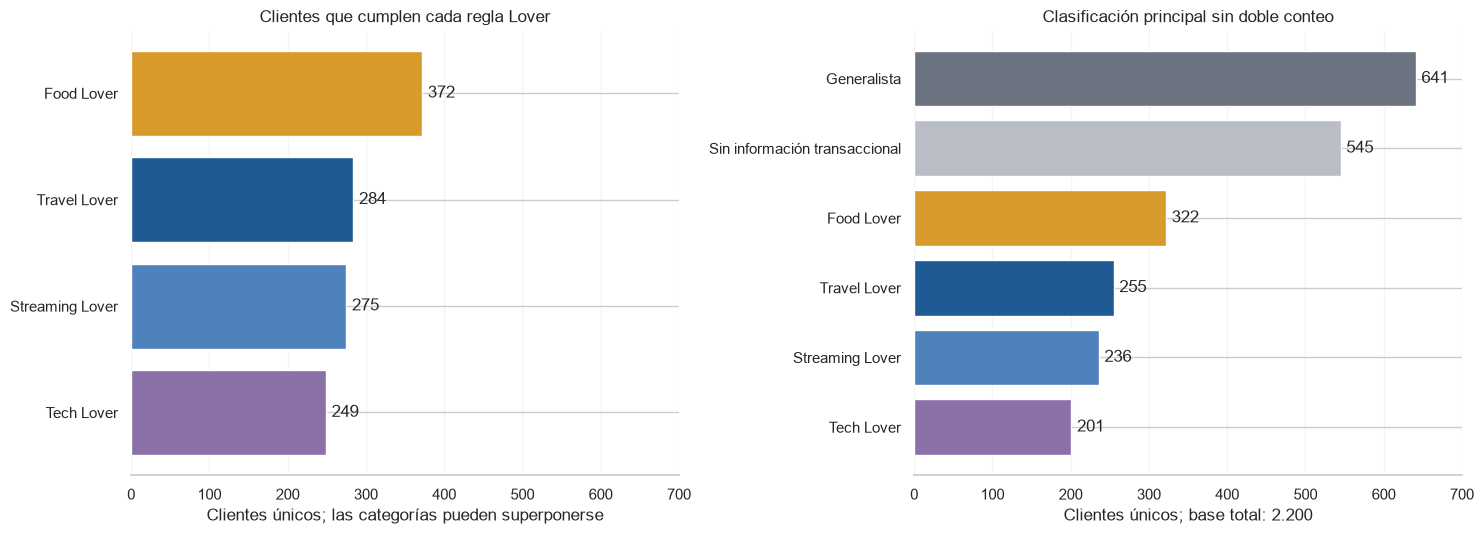

In [35]:
figure, axes = plt.subplots(1, 2, figsize=(15, 5.5))
lover_colors = ["#1F5A94", "#4F81BD", "#D79A2B", "#8A6FA8"]

candidate_plot = lover_candidate_counts.sort_values()
candidate_bars = axes[0].barh(
    candidate_plot.index,
    candidate_plot.values,
    color=[lover_colors[LOVER_ORDER.index(label)] for label in candidate_plot.index],
)
axes[0].bar_label(candidate_bars, padding=4, fmt="{:,.0f}")
axes[0].set_title("Clientes que cumplen cada regla Lover")
axes[0].set_xlabel("Clientes únicos; las categorías pueden superponerse")
axes[0].set_ylabel("")

principal_colors = {
    **dict(zip(LOVER_ORDER, lover_colors)),
    GENERALIST_LABEL: "#6B7280",
    NO_TRANSACTION_LABEL: "#B8BDC6",
}
principal_plot = principal_distribution.sort_values()
principal_bars = axes[1].barh(
    principal_plot.index,
    principal_plot.values,
    color=[principal_colors[label] for label in principal_plot.index],
)
axes[1].bar_label(principal_bars, padding=4, fmt="{:,.0f}")
axes[1].set_title("Clasificación principal sin doble conteo")
axes[1].set_xlabel("Clientes únicos; base total: 2.200")
axes[1].set_ylabel("")

for axis in axes:
    axis.grid(axis="x", alpha=0.2)
    axis.spines[["top", "right", "left"]].set_visible(False)
    axis.set_xlim(0, max(axis.get_xlim()[1], 700))

plt.tight_layout()
plt.show()

**Lectura:** 1.014 clientes cumplen al menos una regla y 157 cumplen más de una. Las barras de la izquierda no deben sumarse porque existe superposición. La clasificación principal de la derecha sí cubre exactamente los 2.200 clientes y puede utilizarse en una visualización de composición.

## 28. Enriquecer la dimensión y cliente 360

Las mismas siete variables se añaden a las dos vistas de cliente. `dim_clientes` permitirá filtrar los hechos en Power BI y `cliente_360` será la fuente directa para React. No se agregan estas etiquetas al dataset a nivel registro para evitar redundancia y una granularidad engañosa.

In [36]:
SEGMENTATION_EXPORT_COLUMNS = [
    "cliente_id",
    *LOVER_FLAGS,
    "cantidad_lovers",
    "lovers",
    "lover_principal",
]

client_dimension = client_dimension.drop(
    columns=SEGMENTATION_EXPORT_COLUMNS[1:], errors="ignore"
).merge(
    segmentation[SEGMENTATION_EXPORT_COLUMNS],
    on="cliente_id",
    how="left",
    validate="one_to_one",
)
client_360 = client_360.drop(
    columns=SEGMENTATION_EXPORT_COLUMNS[1:] + ["lovers_lista"],
    errors="ignore",
).merge(
    segmentation[
        SEGMENTATION_EXPORT_COLUMNS + ["lovers_lista"]
    ],
    on="cliente_id",
    how="left",
    validate="one_to_one",
)

display(
    client_360[
        [
            "cliente_id",
            "cantidad_consumos",
            *LOVER_FLAGS,
            "cantidad_lovers",
            "lovers",
            "lover_principal",
        ]
    ].head(10)
)

,cliente_id,cantidad_consumos,es_travel_lover,es_streaming_lover,es_food_lover,es_tech_lover,cantidad_lovers,lovers,lover_principal
0,C000001,10,False,False,False,True,1,Tech Lover,Tech Lover
1,C000002,5,False,False,False,False,0,,Generalista
2,C000003,7,False,False,True,False,1,Food Lover,Food Lover
3,C000004,0,False,False,False,False,0,,Sin información transaccional
4,C000005,0,False,False,False,False,0,,Sin información transaccional
5,C000006,4,False,False,False,False,0,,Generalista
6,C000007,8,True,False,True,False,2,Travel Lover|Food Lover,Travel Lover
7,C000008,12,False,False,True,False,1,Food Lover,Food Lover
8,C000009,8,False,False,False,False,0,,Generalista
9,C000010,14,False,False,False,False,0,,Generalista


## 29. Analizar perfiles y oportunidades

Además de describir los segmentos, se calculan métricas que preparan los mensajes de negocio para React y Power BI. Los promedios se muestran junto con las medianas porque una proporción pequeña de consumos concentra una parte importante del monto.

In [37]:
principal_profile = (
    client_360.groupby("lover_principal", observed=True)
    .agg(
        clientes=("cliente_id", "size"),
        consumo_total=("consumo_total", "sum"),
        consumo_promedio_cliente=("consumo_total", "mean"),
        consumo_mediano_cliente=("consumo_total", "median"),
        transacciones_promedio=("cantidad_consumos", "mean"),
        ingreso_promedio=("ingreso_estimado", "mean"),
        proporcion_multiproducto=("es_multiproducto", "mean"),
    )
    .reindex(principal_order)
)

card_products = product_fact.loc[
    product_fact["producto"].eq("Tarjeta de Crédito")
].copy()
weighted_card_utilization = float(
    card_products["saldo_producto"].sum()
    / card_products["cupo_credito"].sum()
)

expiration_days = (
    product_fact["fecha_vencimiento"] - cutoff_date
).dt.days
expirations_30_days = int(expiration_days.between(1, 30).sum())
expirations_90_days = int(expiration_days.between(1, 90).sum())
expiration_summary = pd.DataFrame(
    {
        "Vencen en 30 días": product_fact.loc[
            expiration_days.between(1, 30), "producto"
        ].value_counts(),
        "Vencen en 90 días": product_fact.loc[
            expiration_days.between(1, 90), "producto"
        ].value_counts(),
    }
).fillna(0).astype(int)

outlier_consumptions = consumption_fact.loc[
    consumption_fact["consumo_outlier_iqr"]
]
outlier_transaction_share = float(
    len(outlier_consumptions) / len(consumption_fact)
)
outlier_amount_share = float(
    outlier_consumptions["monto_consumo"].sum()
    / consumption_fact["monto_consumo"].sum()
)
outlier_clients = int(outlier_consumptions["cliente_id"].nunique())

card_client_ids = set(card_products["cliente_id"])
no_transaction_client_ids = set(
    segmentation.loc[
        segmentation["lover_principal"].eq(NO_TRANSACTION_LABEL),
        "cliente_id",
    ]
)
no_card_client_ids = set(client_dimension["cliente_id"]) - card_client_ids

business_kpis = pd.DataFrame(
    [
        ["Clientes con al menos un Lover", int(segmentation["cantidad_lovers"].gt(0).sum()), "clientes"],
        ["Clientes multilabel", int(segmentation["cantidad_lovers"].gt(1).sum()), "clientes"],
        ["Clientes sin información transaccional", len(no_transaction_client_ids), "clientes"],
        ["Utilización ponderada de tarjeta", weighted_card_utilization, "porcentaje"],
        ["Vencimientos en 30 días", expirations_30_days, "productos"],
        ["Vencimientos en 90 días", expirations_90_days, "productos"],
        ["Consumos marcados como outlier", len(outlier_consumptions), "consumos"],
        ["Participación de monto de outliers", outlier_amount_share, "porcentaje"],
    ],
    columns=["KPI", "Valor", "Unidad"],
)

display(
    principal_profile.style.format(
        {
            "consumo_total": "{:,.2f}",
            "consumo_promedio_cliente": "{:,.2f}",
            "consumo_mediano_cliente": "{:,.2f}",
            "transacciones_promedio": "{:.2f}",
            "ingreso_promedio": "{:,.2f}",
            "proporcion_multiproducto": "{:.1%}",
        }
    )
)
display(expiration_summary)
display(business_kpis)

,clientes,consumo_total,consumo_promedio_cliente,consumo_mediano_cliente,transacciones_promedio,ingreso_promedio,proporcion_multiproducto
lover_principal,,,,,,,
Travel Lover,255,"313,736.70","1,230.34",754.47,9.24,"1,900.24",92.5%
Streaming Lover,236,"276,146.63","1,170.11",792.44,9.07,"1,936.25",90.7%
Food Lover,322,"375,655.34","1,166.63",830.32,9.57,"1,824.88",90.7%
Tech Lover,201,"213,581.89","1,062.60",712.43,9.71,"1,656.29",90.0%
Generalista,641,"683,320.45","1,066.02",667.54,8.33,"1,842.21",91.7%
Sin información transaccional,545,0.00,0.00,0.00,0.00,"1,824.89",50.6%


,Vencen en 30 días,Vencen en 90 días
producto,,
Crédito Hipotecario,0,15
Crédito Vehicular,0,19
Crédito de Consumo,0,21
Tarjeta de Crédito,22,98


,KPI,Valor,Unidad
0,Clientes con al menos un Lover,"1,014.00",clientes
1,Clientes multilabel,157.00,clientes
2,Clientes sin información transaccional,545.00,clientes
3,Utilización ponderada de tarjeta,0.33,porcentaje
4,Vencimientos en 30 días,22.00,productos
5,Vencimientos en 90 días,153.00,productos
6,Consumos marcados como outlier,"1,231.00",consumos
7,Participación de monto de outliers,0.38,porcentaje


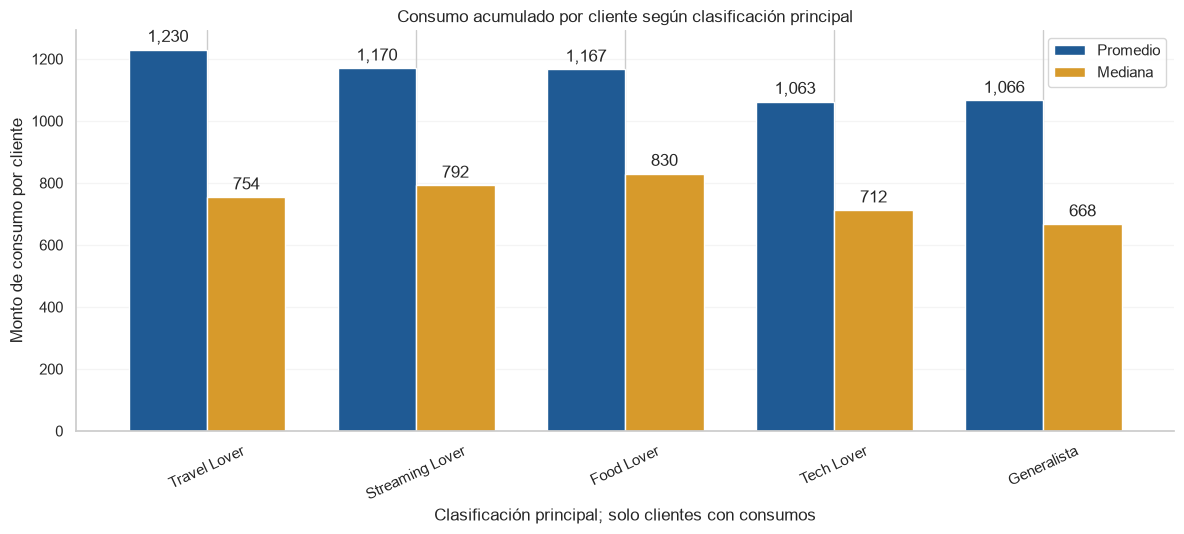

In [38]:
transactional_profile = principal_profile.drop(
    index=NO_TRANSACTION_LABEL
)
comparison = transactional_profile[
    ["consumo_promedio_cliente", "consumo_mediano_cliente"]
].rename(
    columns={
        "consumo_promedio_cliente": "Promedio",
        "consumo_mediano_cliente": "Mediana",
    }
)

axis = comparison.plot(
    kind="bar",
    figsize=(12, 5.5),
    color=["#1F5A94", "#D79A2B"],
    width=0.75,
)
axis.set_title("Consumo acumulado por cliente según clasificación principal")
axis.set_xlabel("Clasificación principal; solo clientes con consumos")
axis.set_ylabel("Monto de consumo por cliente")
axis.tick_params(axis="x", rotation=25)
axis.grid(axis="y", alpha=0.2)
axis.spines[["top", "right"]].set_visible(False)
for container in axis.containers:
    axis.bar_label(container, fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

## 30. Insights accionables

### 1. Existe una base relevante para personalización

**Evidencia:** 1.014 clientes (46,09% de la base) cumplen al menos una regla Lover y 157 cumplen más de una. **Interpretación:** hay señales suficientes para diseñar ofertas temáticas, conservando la superposición. **Acción:** CRM o Marketing puede probar campañas diferenciadas por Lover. **KPI:** tasa de conversión e incremento de consumo frente a un grupo de control. **Limitación:** la regla es heurística y no prueba preferencia futura.

### 2. Los Generalistas requieren una estrategia distinta

**Evidencia:** 641 clientes son Generalistas, el grupo principal más grande entre los 1.655 clientes con consumos. **Interpretación:** su gasto está más distribuido o no alcanza recurrencia suficiente en las cuatro categorías. **Acción:** probar beneficios amplios o recopilar más comportamiento antes de especializar la oferta. **KPI:** conversión, consumo incremental y migración hacia una señal estable. **Limitación:** no cumplir la regla no significa falta de valor comercial.

### 3. “Sin información transaccional” no significa inactividad

**Evidencia:** los 545 clientes sin consumos coinciden exactamente con quienes no tienen tarjeta de crédito observada. **Interpretación:** el dataset no permite distinguir falta de interés, elegibilidad o ausencia de producto. **Acción:** Producto y Riesgo pueden evaluar una campaña de adquisición solo después de aplicar criterios de elegibilidad. **KPI:** clientes elegibles, aprobación, activación y primera compra. **Limitación:** faltan variables de riesgo, contacto y propensión.

### 4. Los vencimientos permiten una acción inmediata

**Evidencia:** 22 productos vencen en 30 días —todos tarjetas— y 153 vencen en 90 días desde 2026-08-31. **Interpretación:** existe una población concreta para comunicación preventiva. **Acción:** Operaciones puede priorizar renovaciones y recordatorios. **KPI:** porcentaje renovado antes del vencimiento y contactos efectivos. **Limitación:** la fecha de corte es fija y no existen datos de contacto ni historial de renovación.

### 5. Los valores extremos son pocos, pero materiales

**Evidencia:** 1.231 consumos marcados por IQR equivalen a 8,28% de las transacciones y 37,63% del monto, distribuidos entre 541 clientes. **Interpretación:** eliminarlos automáticamente distorsionaría el valor observado. **Acción:** Analítica y Riesgo deben revisarlos con reglas de negocio antes de usarlos en campañas o alertas. **KPI:** proporción revisada, falsos positivos y monto validado. **Limitación:** IQR detecta valores inusuales, no fraude ni error.

Ninguno de estos patrones demuestra causalidad. Las acciones propuestas deben evaluarse con comparación válida —idealmente un grupo de control— antes de atribuir un cambio a la segmentación.

## 31. Exportar y validar la Fase 3

Se sobrescriben únicamente las vistas de cliente y el reporte de control. Los archivos de registro, productos y consumos deben conservar exactamente el mismo contenido producido en la Fase 2.

In [39]:
client_dimension.to_csv(DIM_CLIENTS_PATH, **csv_options)
client_360.drop(columns=["productos_lista", "lovers_lista"]).to_csv(
    CLIENT_360_CSV_PATH, **csv_options
)

client_360_json_frame = client_360.copy()
client_360_json_frame["fecha_ultimo_consumo"] = client_360_json_frame[
    "fecha_ultimo_consumo"
].dt.strftime("%Y-%m-%d")
client_360_json_frame["productos"] = client_360_json_frame[
    "productos_lista"
]
client_360_json_frame["lovers"] = client_360_json_frame[
    "lovers_lista"
]
client_360_json_frame = client_360_json_frame.drop(
    columns=["productos_lista", "lovers_lista"]
)
client_360_json_frame = client_360_json_frame.astype(object).where(
    client_360_json_frame.notna(), None
)
client_360_records = client_360_json_frame.to_dict(orient="records")
CLIENT_360_JSON_PATH.write_text(
    json.dumps(client_360_records, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

output_manifest = {
    str(path.relative_to(PROJECT_ROOT)): {
        "filas": rows,
        "clave": key,
        "sha256": file_sha256(path),
    }
    for path, rows, key in output_specs
}
quality_report["fase"] = 4
quality_report["segmentacion_lovers"] = {
    "version": "lover_v1",
    "fecha_corte": cutoff_date.date().isoformat(),
    "poblacion_consumos": len(consumption_fact),
    "regla": {
        "minimo_consumos_categoria": MIN_LOVER_CONSUMPTIONS,
        "minimo_participacion_consumo_total": MIN_LOVER_SHARE,
        "categorias": list(LOVER_LABEL_BY_CATEGORY),
        "denominador": "Consumo positivo total del cliente en las diez categorías",
    },
    "conteos_multilabel": lover_candidate_counts.to_dict(),
    "clientes_con_lovers": int(segmentation["cantidad_lovers"].gt(0).sum()),
    "clientes_multilabel": int(segmentation["cantidad_lovers"].gt(1).sum()),
    "distribucion_principal": principal_distribution.to_dict(),
    "empates_participacion_maxima": maximum_share_ties,
}
quality_report["reconciliacion"]["saldo_tarjetas"] = round(
    float(card_products["saldo_producto"].sum()), 2
)
quality_report["reconciliacion"]["cupo_total_tarjetas"] = round(
    float(card_products["cupo_credito"].sum()), 2
)
quality_report["metricas_negocio"] = {
    "utilizacion_ponderada_tarjeta": round(weighted_card_utilization, 6),
    "vencimientos_30_dias": expirations_30_days,
    "vencimientos_90_dias": expirations_90_days,
    "consumos_outlier": len(outlier_consumptions),
    "clientes_con_consumos_outlier": outlier_clients,
    "participacion_transacciones_outlier": round(outlier_transaction_share, 6),
    "participacion_monto_outlier": round(outlier_amount_share, 6),
}
quality_report["integracion_react"] = {
    "vista": "data/processed/cliente_360.json",
    "campo_utilizacion_numerador": "saldo_tarjetas_conocido",
    "campo_utilizacion_denominador": "cupo_total_tarjetas",
    "moneda_visualizacion": "USD (supuesto; la fuente no informa moneda)",
}
quality_report["salidas"] = output_manifest
QUALITY_REPORT_PATH.write_text(
    json.dumps(quality_report, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

display(
    pd.DataFrame(
        [
            [path, details["filas"], details["clave"], details["sha256"][:12]]
            for path, details in output_manifest.items()
        ],
        columns=["Archivo", "Filas", "Clave", "SHA-256 (inicio)"],
    )
)

,Archivo,Filas,Clave,SHA-256 (inicio)
0,data/dataset_clean.csv,22342,registro_id,0d32838b0c61
1,data/processed/dim_clientes.csv,2200,cliente_id,73b8a4053d83
2,data/processed/fact_productos.csv,5048,cliente_producto_id,67579cbfd350
3,data/processed/fact_consumos.csv,14873,consumo_id,0deb1199d6f8
4,data/processed/cliente_360.csv,2200,cliente_id,62e758eb07f1
5,data/processed/cliente_360.json,2200,cliente_id,f15c6f4094cf


In [40]:
clients_phase_3 = pd.read_csv(DIM_CLIENTS_PATH, encoding="utf-8")
client_360_phase_3 = pd.read_csv(CLIENT_360_CSV_PATH, encoding="utf-8")
client_360_json_phase_3 = json.loads(
    CLIENT_360_JSON_PATH.read_text(encoding="utf-8")
)
quality_report_phase_3 = json.loads(
    QUALITY_REPORT_PATH.read_text(encoding="utf-8")
)

expected_candidate_counts = {
    "Travel Lover": 284,
    "Streaming Lover": 275,
    "Food Lover": 372,
    "Tech Lover": 249,
}
expected_principal_distribution = {
    "Travel Lover": 255,
    "Streaming Lover": 236,
    "Food Lover": 322,
    "Tech Lover": 201,
    GENERALIST_LABEL: 641,
    NO_TRANSACTION_LABEL: 545,
}

assert lover_candidate_counts.to_dict() == expected_candidate_counts
assert int(segmentation["cantidad_lovers"].gt(1).sum()) == 157
assert multilabel_distribution.to_dict() == {0: 1186, 1: 857, 2: 148, 3: 9}
assert maximum_share_ties == 0
assert principal_distribution.to_dict() == expected_principal_distribution
assert principal_distribution.sum() == 2200
assert segmentation["lover_principal"].notna().all()
assert segmentation[LOVER_FLAGS].sum(axis=1).eq(
    segmentation["cantidad_lovers"]
).all()
assert segmentation.apply(
    lambda row: all(
        row[LOVER_FLAG_BY_LABEL[label]] for label in row["lovers_lista"]
    ),
    axis=1,
).all()
assert no_transaction_client_ids == no_card_client_ids
assert len(no_transaction_client_ids) == 545

assert len(clients_phase_3) == 2200
assert len(client_360_phase_3) == 2200
assert len(client_360_json_phase_3) == 2200
assert clients_phase_3["cliente_id"].is_unique
assert client_360_phase_3["cliente_id"].is_unique
assert set(SEGMENTATION_EXPORT_COLUMNS).issubset(clients_phase_3.columns)
assert set(SEGMENTATION_EXPORT_COLUMNS).issubset(client_360_phase_3.columns)
assert all(isinstance(row["lovers"], list) for row in client_360_json_phase_3)

csv_principal = client_360_phase_3.set_index("cliente_id")["lover_principal"]
json_principal = {
    row["cliente_id"]: row["lover_principal"]
    for row in client_360_json_phase_3
}
assert csv_principal.to_dict() == json_principal
assert clients_phase_3.set_index("cliente_id")["lover_principal"].to_dict() == json_principal

assert abs(float(consumption_fact["monto_consumo"].sum()) - 1862441.01) < 0.01
assert abs(weighted_card_utilization - 0.32832777398151763) < 1e-12
assert expirations_30_days == 22
assert expirations_90_days == 153
assert len(outlier_consumptions) == 1231
assert outlier_clients == 541
assert abs(outlier_transaction_share - 0.08276743091508102) < 1e-12
assert abs(outlier_amount_share - 0.37630889044909943) < 1e-12

assert file_sha256(DATA_PATH) == EXPECTED_SHA256
assert all(
    file_sha256(path) == original_hash
    for path, original_hash in stable_output_hashes_before_phase_3.items()
)
assert quality_report_phase_3["fase"] == 4
assert abs(client_360_phase_3["saldo_tarjetas_conocido"].sum() - 2018033.83) < 0.01
assert abs(client_360_phase_3["cupo_total_tarjetas"].sum() - 6146400.00) < 0.01
assert abs(
    client_360_phase_3["saldo_tarjetas_conocido"].sum()
    / client_360_phase_3["cupo_total_tarjetas"].sum()
    - weighted_card_utilization
) < 1e-12
assert all(
    "saldo_tarjetas_conocido" in row for row in client_360_json_phase_3
)
assert quality_report_phase_3["validaciones"]["estado"] == "aprobado"
assert not (PROCESSED_DIR / "dataset_clean.csv").exists()

print("Todas las validaciones de la Fase 3 se ejecutaron correctamente.")

Todas las validaciones de la Fase 3 se ejecutaron correctamente.


## Cierre de la Parte III: Lovers e insights

La base queda lista para las siguientes fases con dos formas complementarias de segmentación:

- **Multilabel:** conserva todas las señales que cumple el cliente y sirve para campañas específicas.
- **Principal:** asigna una sola categoría a cada cliente y evita doble conteo en vistas ejecutivas.

Las oportunidades propuestas son hipótesis de acción respaldadas por patrones observados. Una campaña futura deberá medirse con población elegible, comparación válida y KPIs definidos antes de atribuirle resultados.

# Parte IV — Preparación de la vista cliente 360 para React

La aplicación necesita recalcular la utilización ponderada de tarjeta después de aplicar filtros. Por eso se expone `saldo_tarjetas_conocido` junto con `cupo_total_tarjetas` a nivel cliente. No se modifican el dataset limpio, la dimensión ni las tablas de hechos; solo se amplía la vista de consumo de React y se actualiza su trazabilidad.

`saldo_tarjetas_conocido` forma parte de `saldo_deuda_conocido`. No deben sumarse ambas columnas entre sí. La moneda se mostrará como USD en la interfaz por una decisión de presentación; el archivo fuente no contiene una columna de moneda.

In [41]:
react_view_validation = pd.DataFrame(
    [
        ["Clientes", len(client_360_phase_3), 2200],
        ["Saldo de tarjetas", client_360_phase_3["saldo_tarjetas_conocido"].sum(), 2018033.83],
        ["Cupo total de tarjetas", client_360_phase_3["cupo_total_tarjetas"].sum(), 6146400.00],
        [
            "Utilización ponderada",
            client_360_phase_3["saldo_tarjetas_conocido"].sum()
            / client_360_phase_3["cupo_total_tarjetas"].sum(),
            weighted_card_utilization,
        ],
    ],
    columns=["Control para React", "Resultado", "Esperado"],
)
display(react_view_validation)
print("La vista cliente 360 quedó preparada para KPIs filtrables en React.")

,Control para React,Resultado,Esperado
0,Clientes,"2,200.00","2,200.00"
1,Saldo de tarjetas,"2,018,033.83","2,018,033.83"
2,Cupo total de tarjetas,"6,146,400.00","6,146,400.00"
3,Utilización ponderada,0.33,0.33


La vista cliente 360 quedó preparada para KPIs filtrables en React.
